## Список картинок, импорт OCR

In [18]:
import os
import sys
from IPython.display import Image as DisplayImage, display
from PIL import Image, ImageDraw

sys.path.append(os.path.abspath('..'))

In [13]:
memes = [
    os.path.join("../ocr_research/memes", f) 
    for f in os.listdir("../ocr_research/memes") 
    if f.endswith(".jpg")
]

In [14]:
from app.ocr_module import OCRService

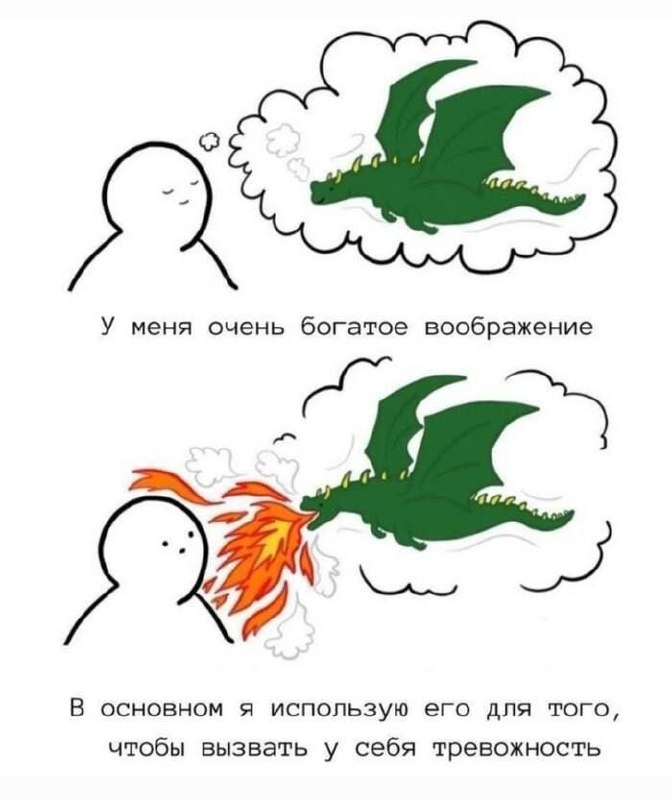

Recognizing Text: 100%|██████████| 4/4 [00:07<00:00,  1.89s/it]

OCRResult(blocks=[TextBlock(coords=(128, 312, 595, 341), text='меня очень богатое воображение', confidence=0.9997968599200249), TextBlock(coords=(66, 693, 622, 723), text='В основном я использую его для того,', confidence=0.9997020003042723), TextBlock(coords=(104, 731, 604, 764), text='чтобы вызвать у себя тревожность', confidence=0.9997718614690444)], full_text='меня очень богатое воображение\nВ основном я использую его для того,\nчтобы вызвать у себя тревожность')


In [15]:
service = OCRService()

display(DisplayImage(filename=memes[0], width=300))
print(service.process(Image.open(memes[0])))

## Убираем текст по координатам найденных блоков

In [37]:
from iopaint.model_manager import ModelManager
from iopaint.schema import InpaintRequest
import numpy as np
import cv2

Создадим маску по координатам блоков:

Detecting bboxes:   0%|          | 0/1 [00:00<?, ?it/s]

Recognizing Text: 100%|██████████| 4/4 [00:18<00:00,  4.58s/it]


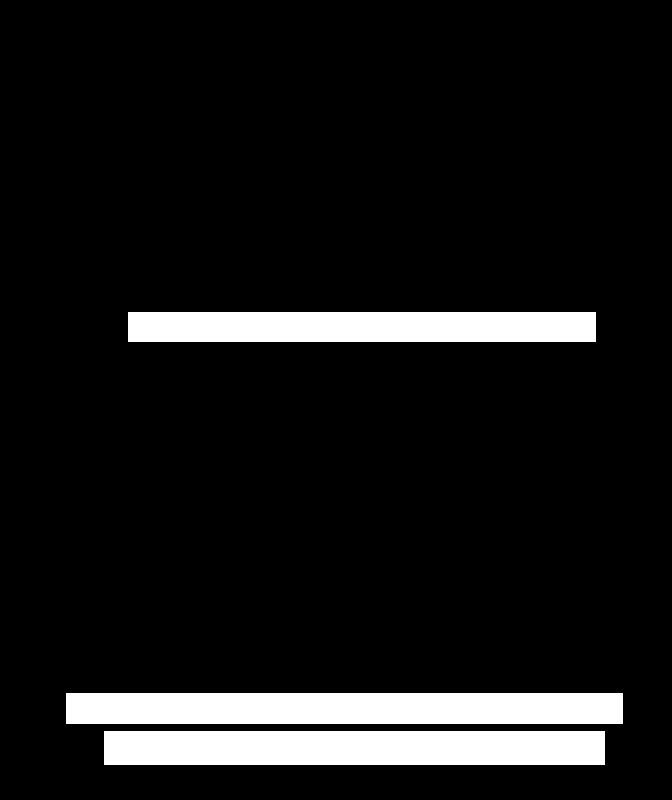

In [21]:
ocr_result = service.process(Image.open(memes[0]))
img = Image.open(memes[0])

mask = Image.new("L", img.size, 0)
draw = ImageDraw.Draw(mask)

for block in ocr_result.blocks:
    x1, y1, x2, y2 = block.coords
    draw.rectangle([x1, y1, x2, y2], fill=255)

display(mask)

2026-04-12 18:30:52.612 | INFO     | iopaint.model_manager:init_model:47 - Loading model: lama
2026-04-12 18:30:52.614 | INFO     | iopaint.helper:load_jit_model:107 - Loading model from: C:\Users\dielo/.cache\torch\hub\checkpoints\big-lama.pt


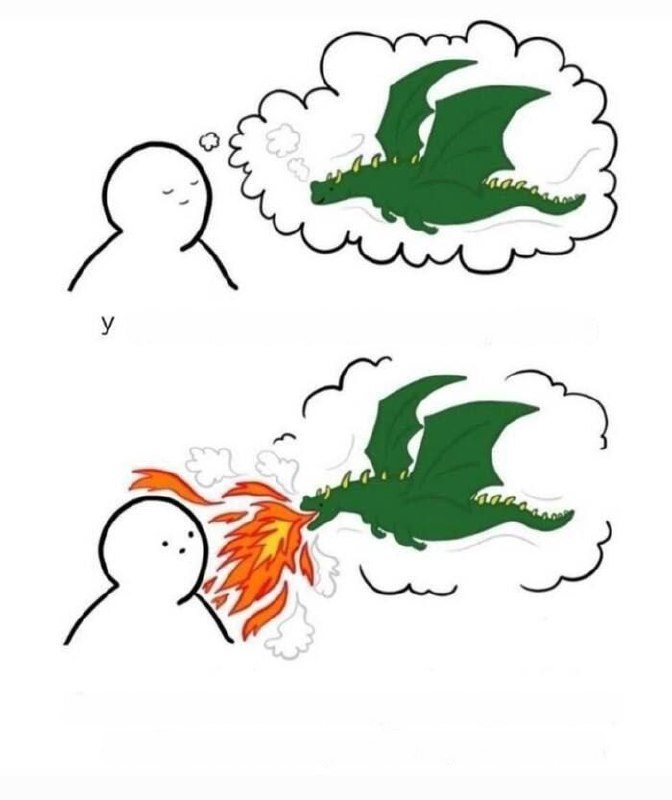

In [39]:
model = ModelManager(name="lama", device="cpu")

img_np = np.array(img)
mask_np = np.array(mask)

config = InpaintRequest()

result = model(
    image=img_np, 
    mask=mask_np, 
    config=config
)

result_img = Image.fromarray(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

display(result_img)

Соберем функцию, которая принимает картинку и возвращает картинку без текста:

In [48]:
def clean_img(img_path, show=False):
    img = Image.open(img_path)
    ocr_result = service.process(img)

    mask = Image.new("L", img.size, 0)
    draw = ImageDraw.Draw(mask)

    for block in ocr_result.blocks:
        x1, y1, x2, y2 = block.coords
        draw.rectangle([x1, y1, x2, y2], fill=255)

    model = ModelManager(name="lama", device="cpu")

    img_np = np.array(img)
    mask_np = np.array(mask)

    config = InpaintRequest()

    result = model(
        image=img_np, 
        mask=mask_np, 
        config=config
    )

    result_img = Image.fromarray(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

    if show:
        new_width = 300

        w_percent = new_width / result_img.width
        new_height = int(result_img.height * w_percent)

        img_resized = result_img.resize((new_width, new_height))

        display(img_resized)

    return result_img, ocr_result

Recognizing Text: 100%|██████████| 3/3 [00:07<00:00,  2.42s/it]
2026-04-12 18:42:10.763 | INFO     | iopaint.model_manager:init_model:47 - Loading model: lama
2026-04-12 18:42:10.764 | INFO     | iopaint.helper:load_jit_model:107 - Loading model from: C:\Users\dielo/.cache\torch\hub\checkpoints\big-lama.pt
2026-04-12 18:42:11.323 | INFO     | iopaint.model.base:__call__:97 - Run crop strategy


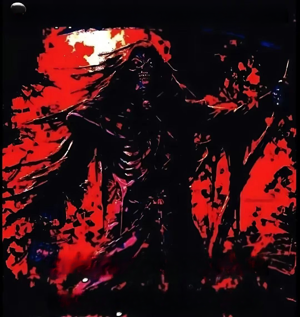

In [45]:
c_img = clean_img(memes[5], True)

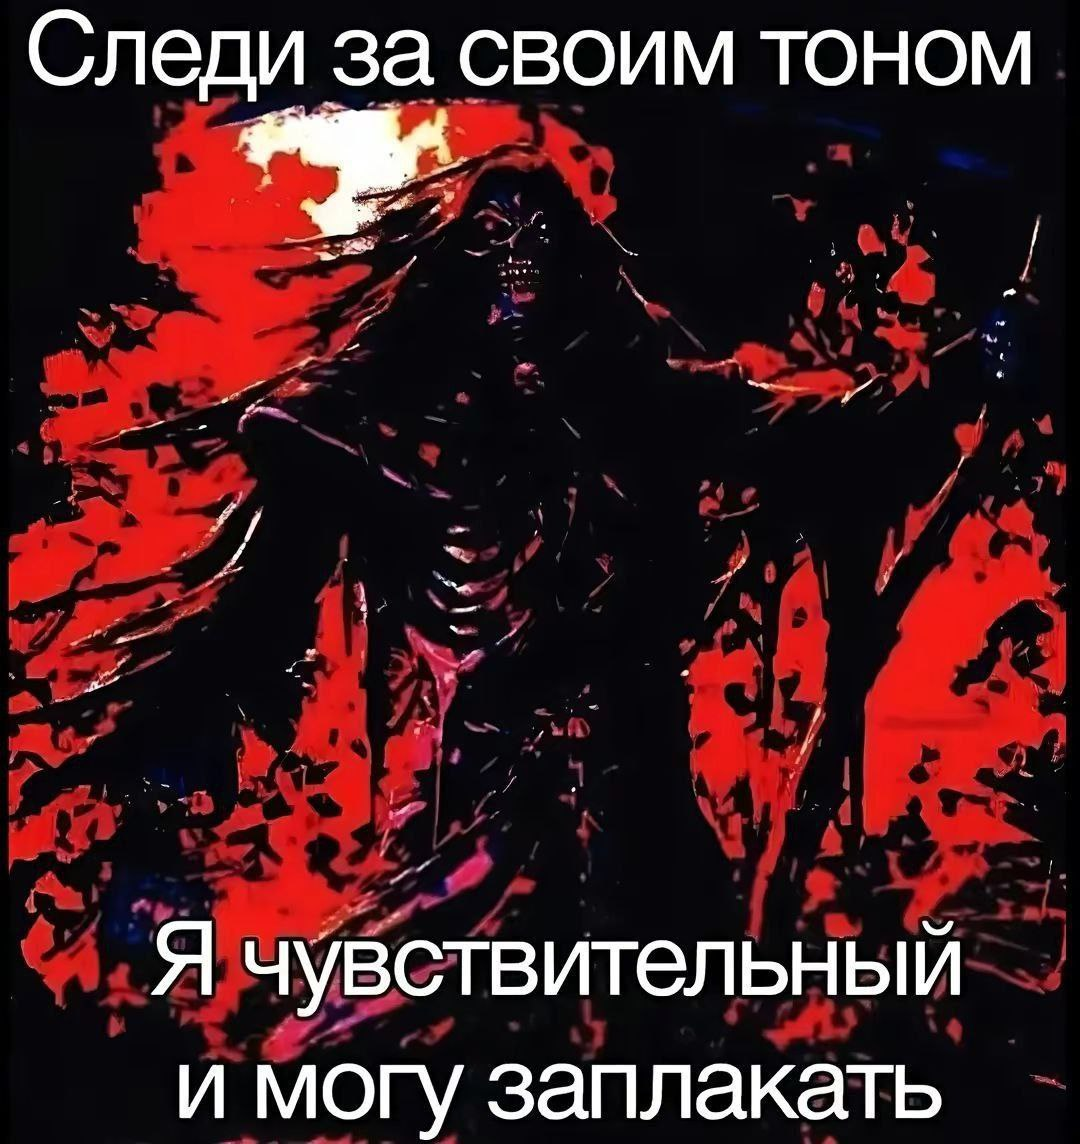

In [46]:
display(DisplayImage(filename=memes[5], width=300))

Для ускорения дальнейшей работы с влм и ллм сохраним результаты обработки OCR, распознанный текст и изображение без текста

In [50]:
import shutil
from pathlib import Path

In [57]:
folder_path = "clean_memes"

if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

os.makedirs(folder_path)

ocr_results = {}

for meme in memes:
    result_img, ocr_result = clean_img(meme)
    result_img.save("clean_memes/" + Path(meme).name)
    
    ocr_results[Path(meme).stem] = ocr_result



Detecting bboxes:   0%|          | 0/1 [00:00<?, ?it/s]

Recognizing Text: 100%|██████████| 4/4 [00:07<00:00,  1.87s/it]
2026-04-12 18:58:13.261 | INFO     | iopaint.model_manager:init_model:47 - Loading model: lama
2026-04-12 18:58:13.261 | INFO     | iopaint.helper:load_jit_model:107 - Loading model from: C:\Users\dielo/.cache\torch\hub\checkpoints\big-lama.pt
Recognizing Text: 100%|██████████| 8/8 [00:12<00:00,  1.62s/it]
2026-04-12 18:58:33.782 | INFO     | iopaint.model_manager:init_model:47 - Loading model: lama
2026-04-12 18:58:33.783 | INFO     | iopaint.helper:load_jit_model:107 - Loading model from: C:\Users\dielo/.cache\torch\hub\checkpoints\big-lama.pt
2026-04-12 18:58:34.340 | INFO     | iopaint.model.base:__call__:97 - Run crop strategy
Recognizing Text: 100%|██████████| 9/9 [00:12<00:00,  1.37s/it]
2026-04-12 18:59:00.586 | INFO     | iopaint.model_manager:init_model:47 - Loading model: lama
2026-04-12 18:59:00.586 | INFO     | iopaint.helper:load_jit_model:107 - Loading model from: C:\Users\dielo/.cache\torch\hub\checkpoints\

## Подбираем VLM и промт для получения визуального контекста

### Moondream

In [58]:
from ollama import chat

In [79]:
def show_result_moondream(img_path, promt):

    response = chat(
        model='moondream:v2',
        messages=[
            {
                'role': 'user',
                'content': promt,
                'images': [img_path]
            }
        ]
    )

    display(DisplayImage(filename=img_path, width=300))
    print(response.message.content)

In [ ]:
meme_keys = list(ocr_results.keys())

Покрутим промт для получения хорошего результата на нескольких изображениях:

In [107]:
promt_moondream = """
You are describing aт image for a person who cannot see it.

IMPORTANT:
- Do NOT analyze, interpret, or explain meaning, do not write anything about meaning or interpretation.
- Only describe visible visual content.

OUTPUT FORMAT (STRICT):

If the image has one scene:
Panel 1:
- [detailed description]

If the image has multiple panels:
Panel 1:
- [detailed description]

Panel 2:
- [detailed description]

Panel 3:
- [detailed description]

One object belongs to only one panel

RULES:
- Describe ALL visible objects, characters, text areas (even if unreadable or missing).
- Include actions, positions, emotions (only if visually obvious).
- Do not skip background details.
- Do not merge panels.
- Panels are determined only by visual separation (borders, spacing, layout).
- Use natural reading order: top-to-bottom, left-to-right.
- Never mention "analysis", "image shows", "we can see", just describe directly.
"""

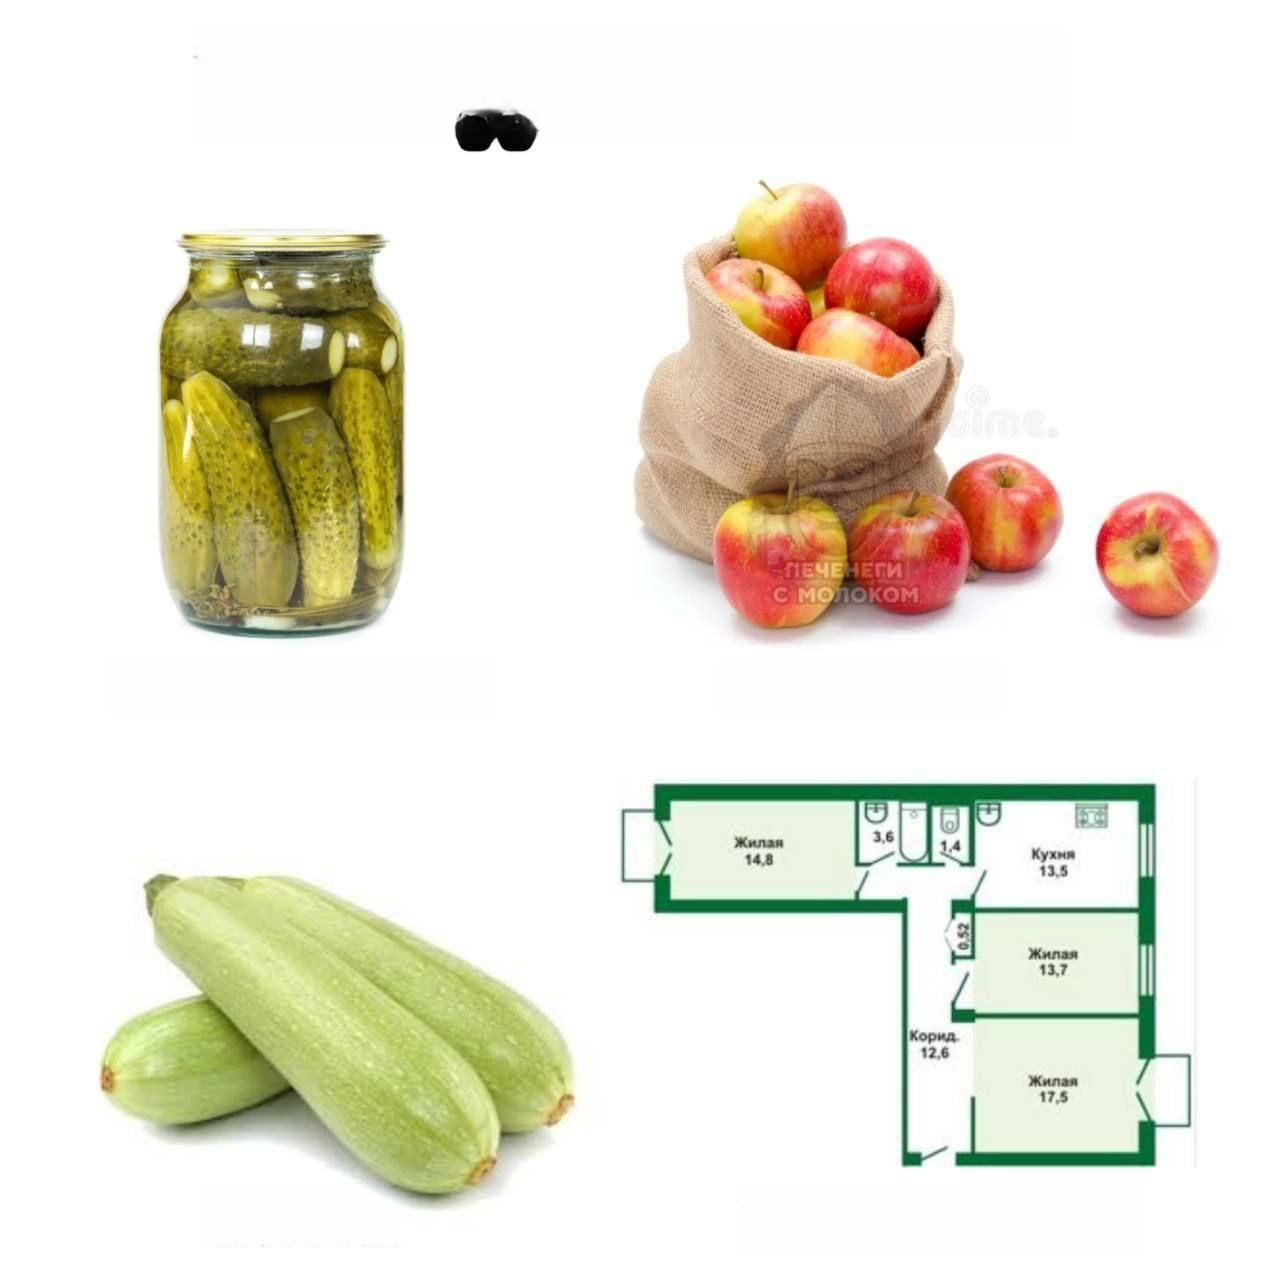


The image is a collage of four different scenes featuring various fruits and vegetables. In the first panel, there are two green cucumbers placed next to each other on a white background. The second panel features an apple sitting in a brown paper bag with several more apples inside. The third panel shows a bunch of red apples arranged together in a basket. Finally, the fourth panel displays a floor plan or layout of a room.


In [108]:
show_result_moondream('clean_memes/' + meme_keys[1] + '.jpg', promt_moondream)

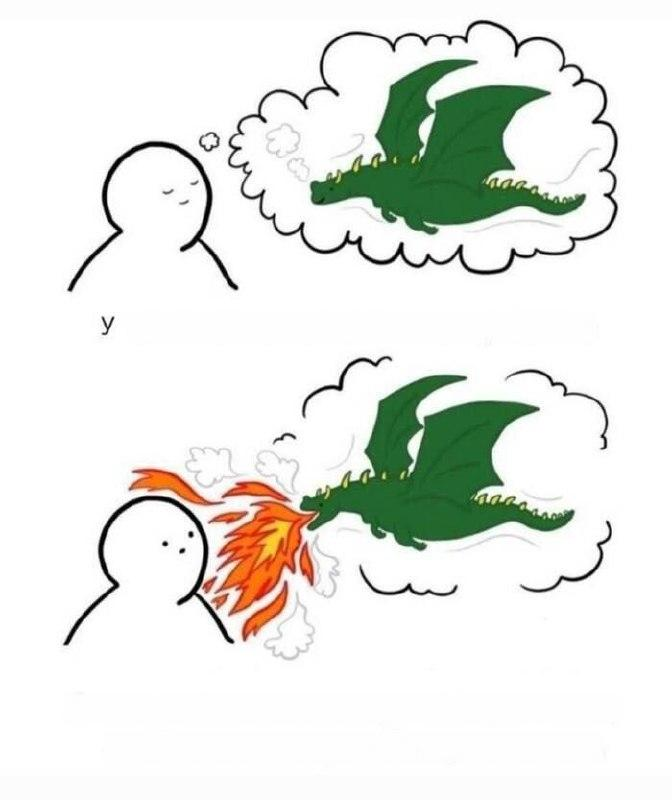


The image is a simple cartoon depicting two people with thought bubbles above their heads. One person has a dragon in his mouth and the other person is thinking about having a dragon breathe fire on him. The panels show different stages of this scene, from the initial thought bubble to the final outcome where the dragon's breath causes damage to the second person's head.

The image does not contain any text or additional objects, making it a straightforward representation of the two characters and their thoughts about the dragon.


In [109]:
show_result_moondream('clean_memes/' + meme_keys[0] + '.jpg', promt_moondream)

Подобран промт, который хорошо работает на 2-3 рассмотренных мемах из начала списка. Посмотрим на результат для 15 случайных картинок:

In [110]:
import random

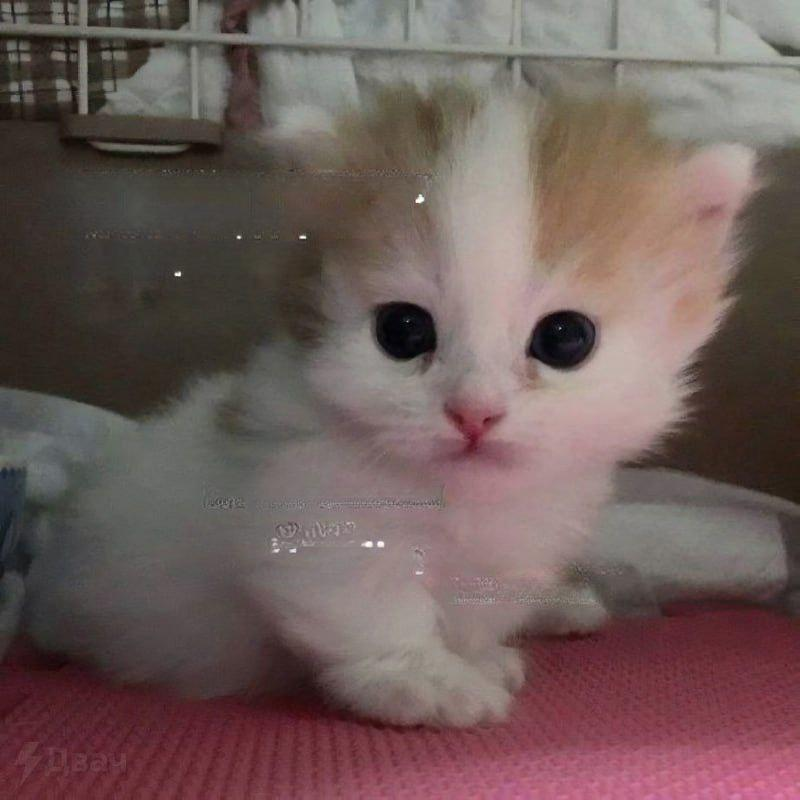


The image features a small kitten with white and brown fur sitting on a pink surface. The kitten is looking at the camera, giving off an impression of curiosity or interest.


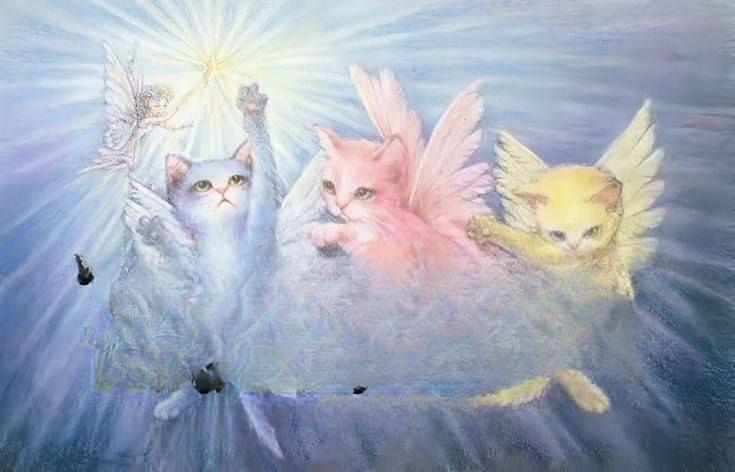


The image is a painting of three cats with wings and a fairy on the left side. The cat in the center has its arms raised up to the sky, while the other two cats are sitting down.


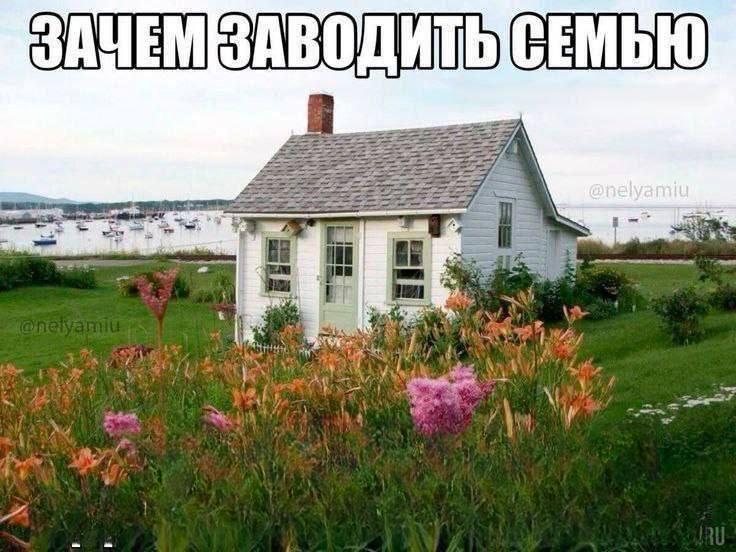


The image is a picture of a small white house with pink flowers in front and a river behind it. The house has a chimney on top, and the sky above appears to be cloudy.


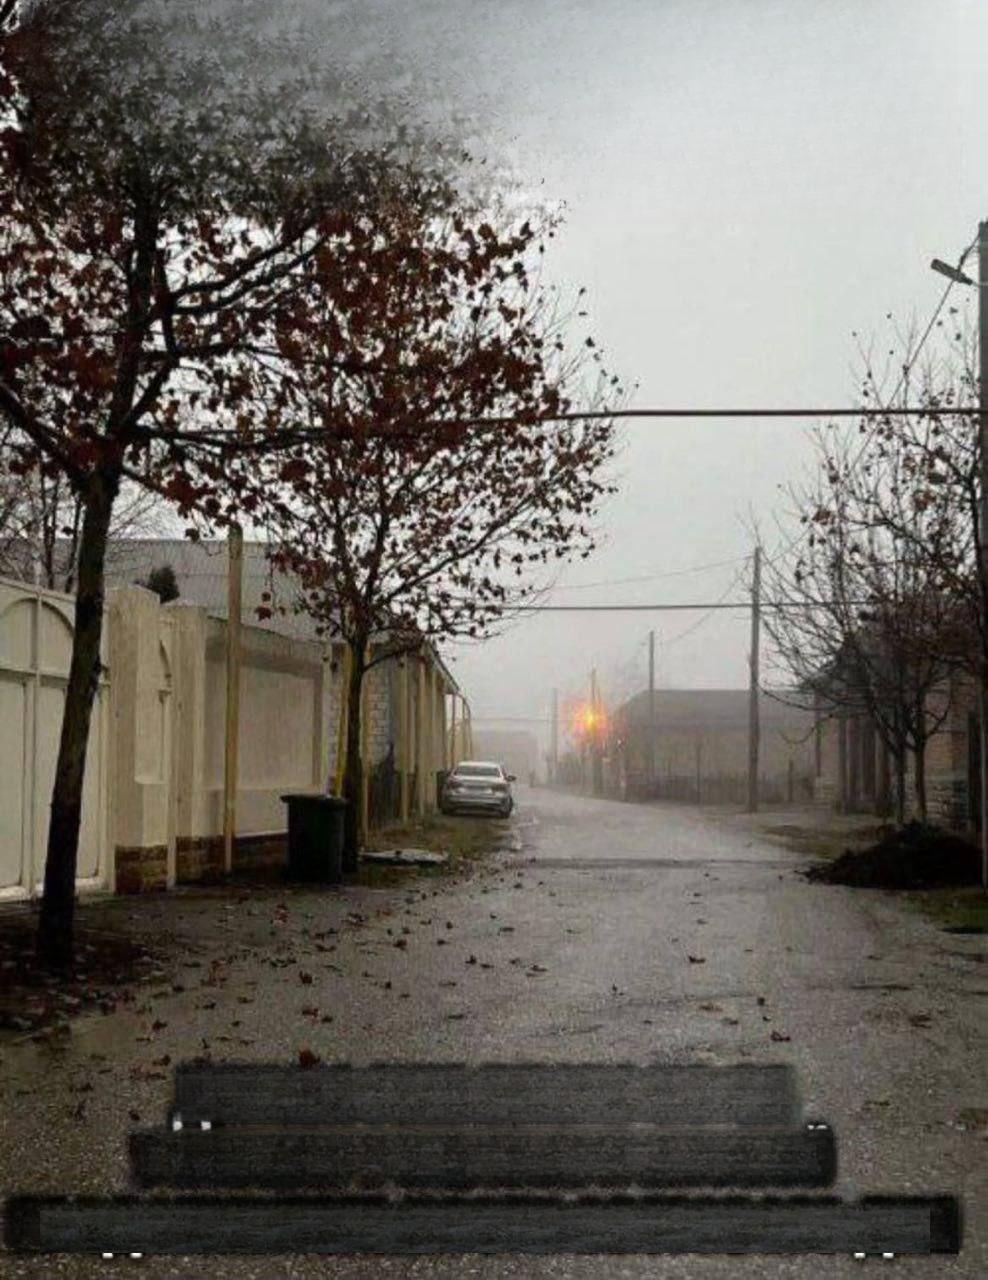


The image is a black and white photograph of an empty street with trees lining the road. The sky above appears to be overcast, casting a gloomy atmosphere over the scene. There are no people or vehicles visible in the photo, adding to the sense of solitude and stillness.


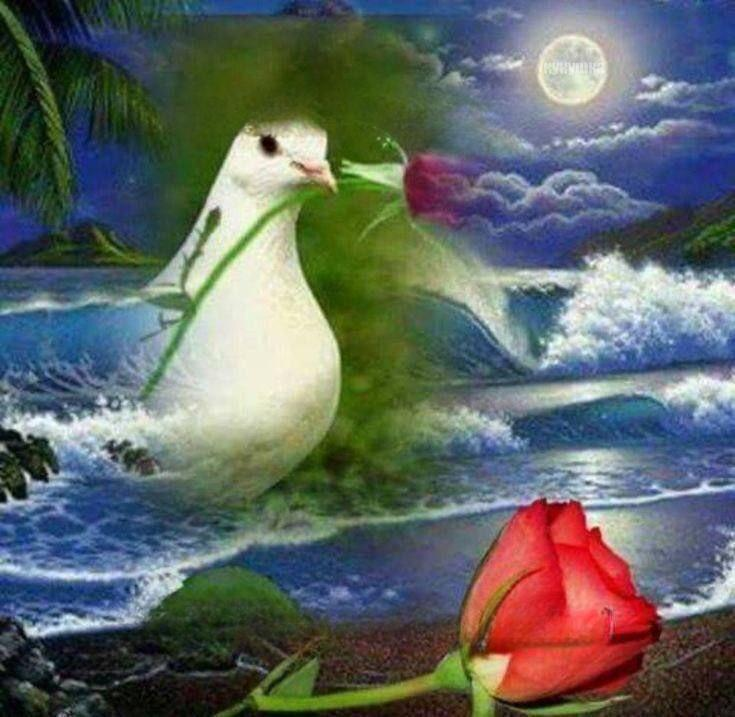


The image is a painting of a white dove holding a rose in its beak and standing on the shoreline with waves crashing behind it. The background features a dark blue sky, water, and mountains.


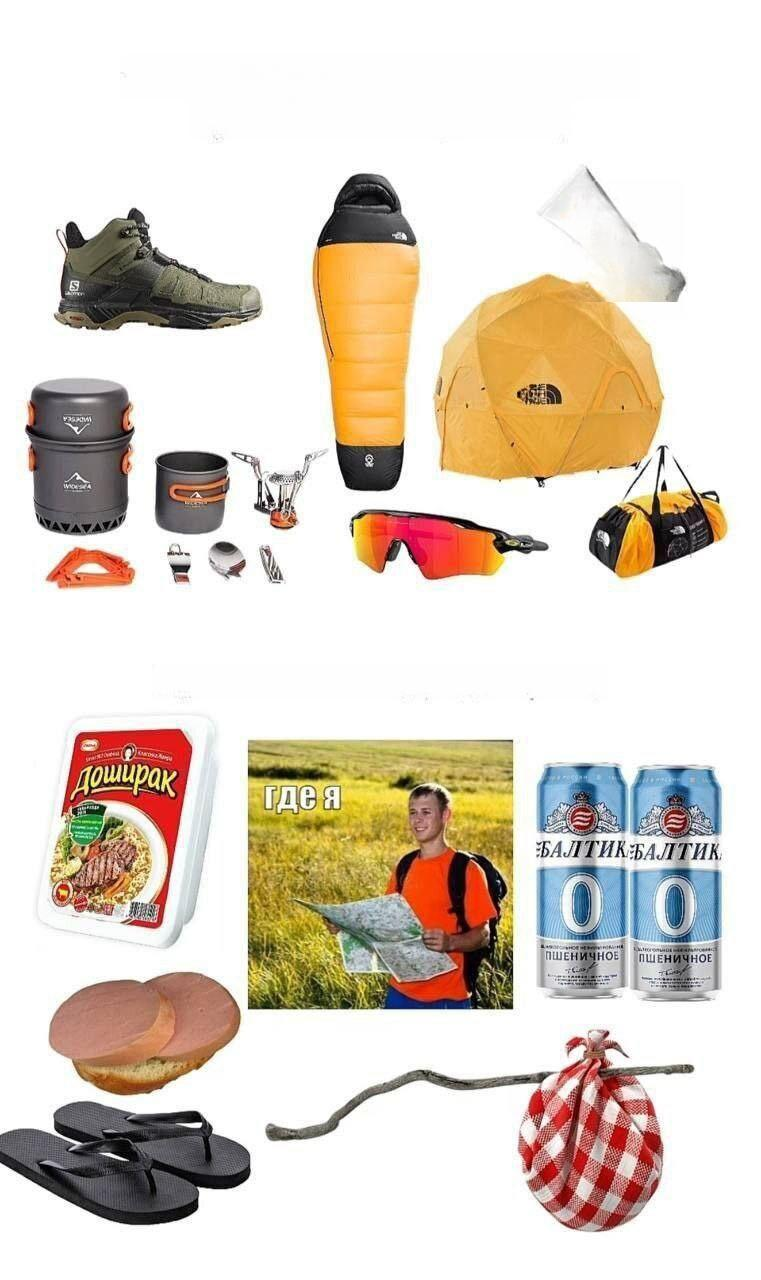


The image is a collage of three panels that show various objects and items related to camping or outdoor activities. The first panel features a pair of sandals, a backpack, and a tent. The second panel includes a sandwich, a water bottle, and an orange umbrella. The third panel shows a person holding a camera with a backpack on their back.


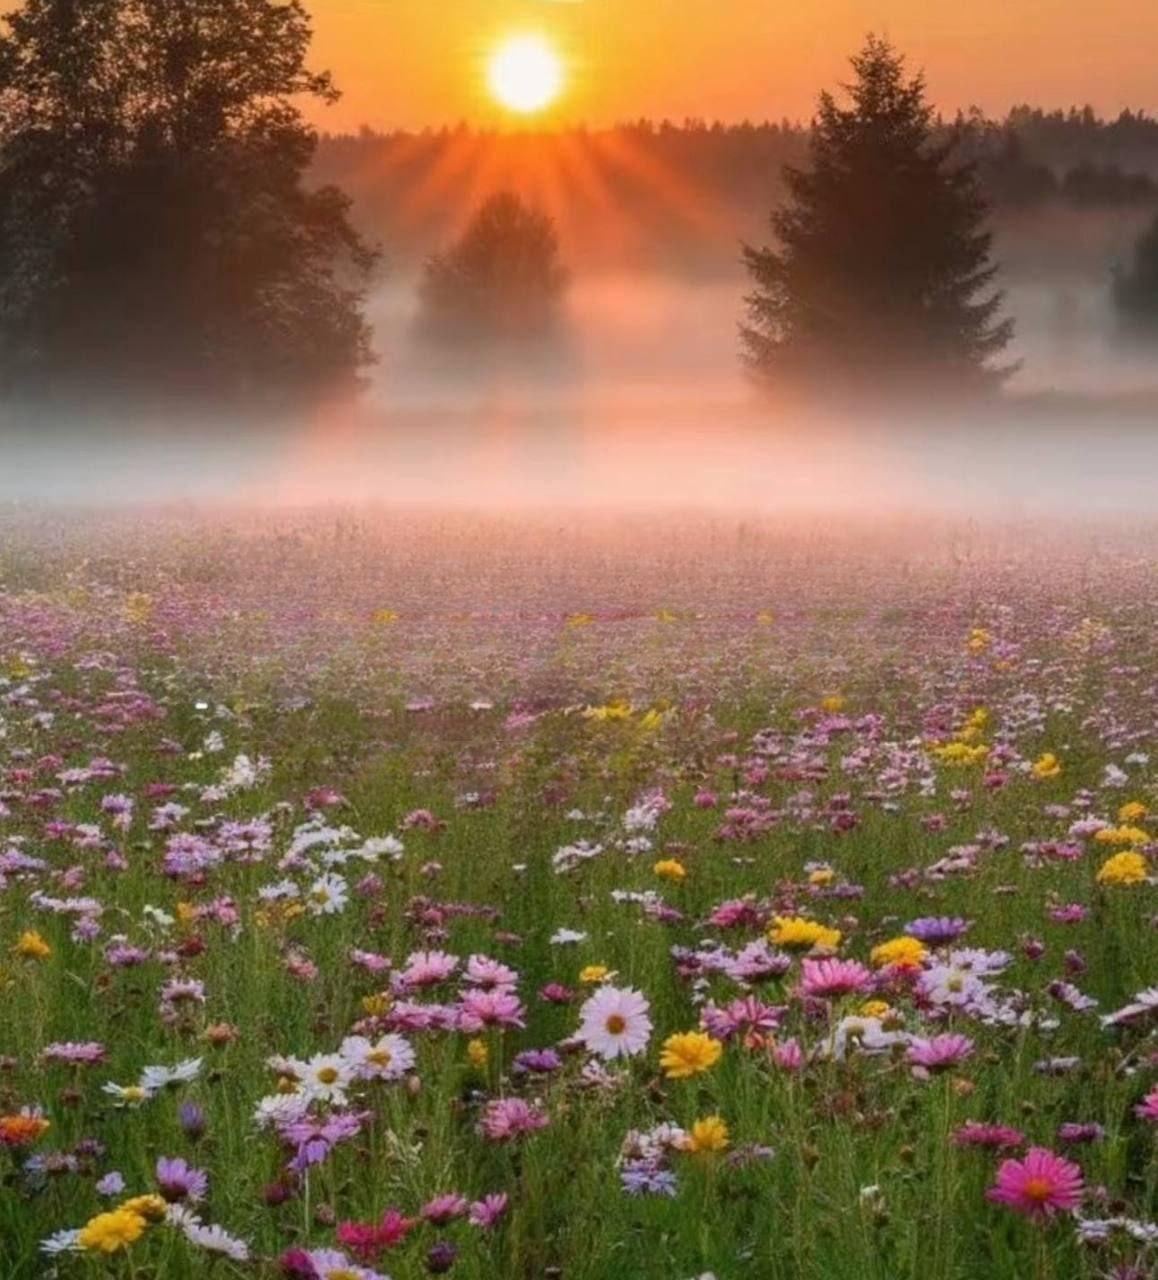


The image is a panoramic view of a field filled with flowers and trees at sunrise or sunset. The sun is shining brightly in the sky, casting its warm glow over the scene. The colors are vibrant, with hues of pink, yellow, white, and green dominating the landscape. The flowers vary in size and shape, adding to the diversity of the scene. The field extends towards a line of trees on the right side, providing a sense of depth and perspective.


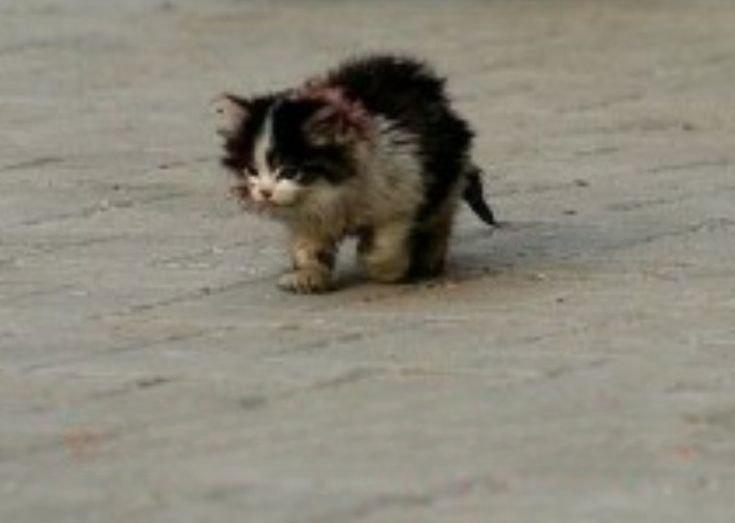


The image is a black and white photo of a small kitten walking on the ground. The kitten appears to be dirty or wet, possibly due to rain or other environmental factors. It is standing in the center of the frame, with no other objects or characters visible around it.


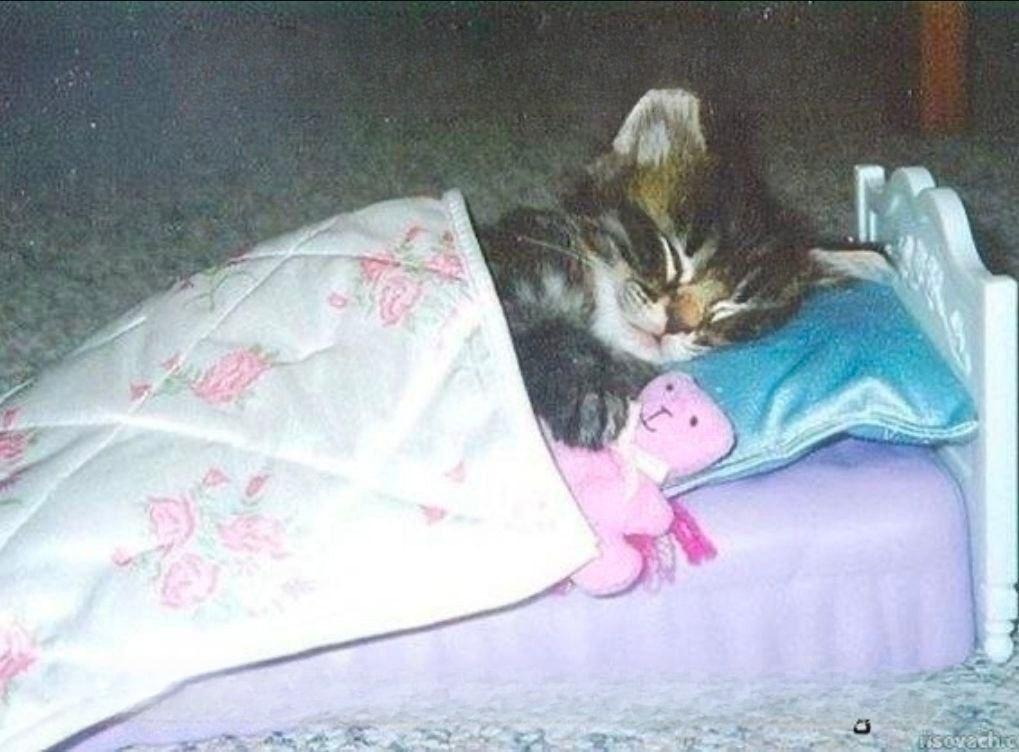


The image features a small kitten sleeping on a bed with a pink teddy bear next to it. The scene is set against the backdrop of a white wall, and there are no texts or other objects in the image.


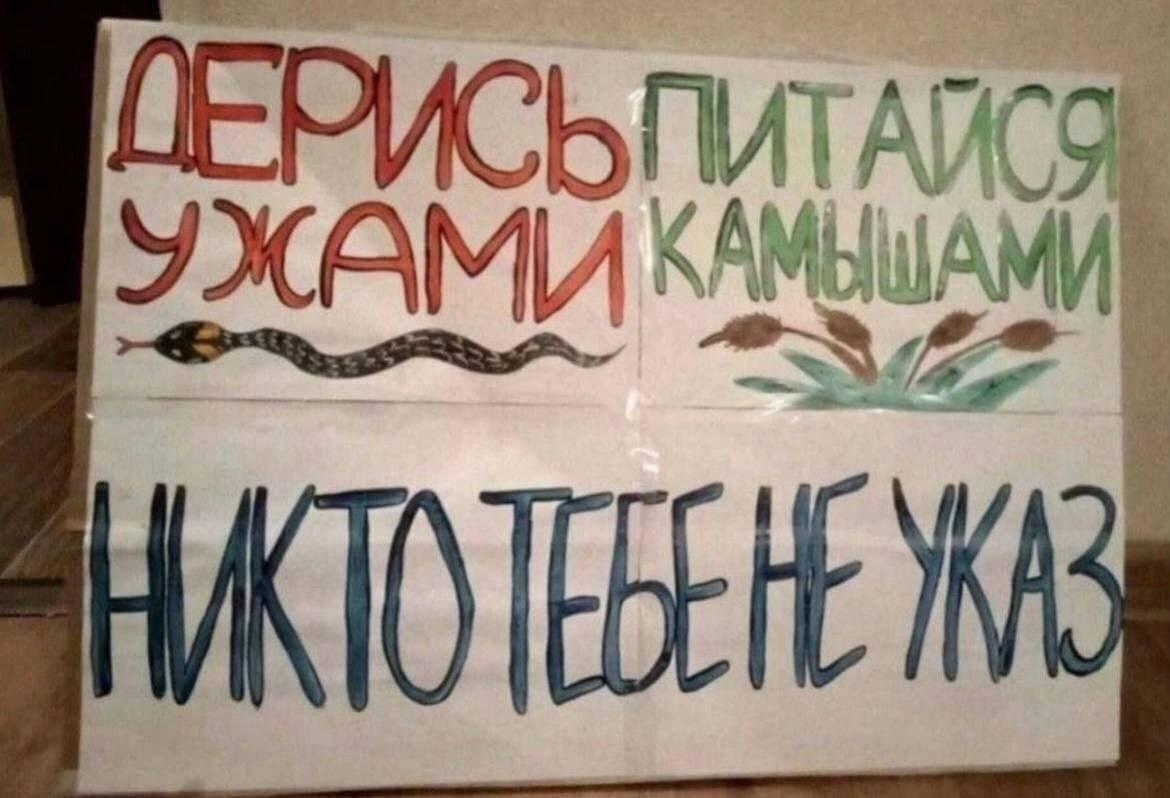


The image is a single scene with three panels of text in Russian and English. The first panel has the words "Рестановочник для приветок" (Spanish to English), which translates to "Spanish to English". The second panel has the words "Сбербанк для приветок", which translates to "Spanish to English". The third panel is a blank white rectangle with no text.

The image does not contain any objects or actions, and there are no visible emotions. It appears to be a simple scene of three panels in Russian and English.


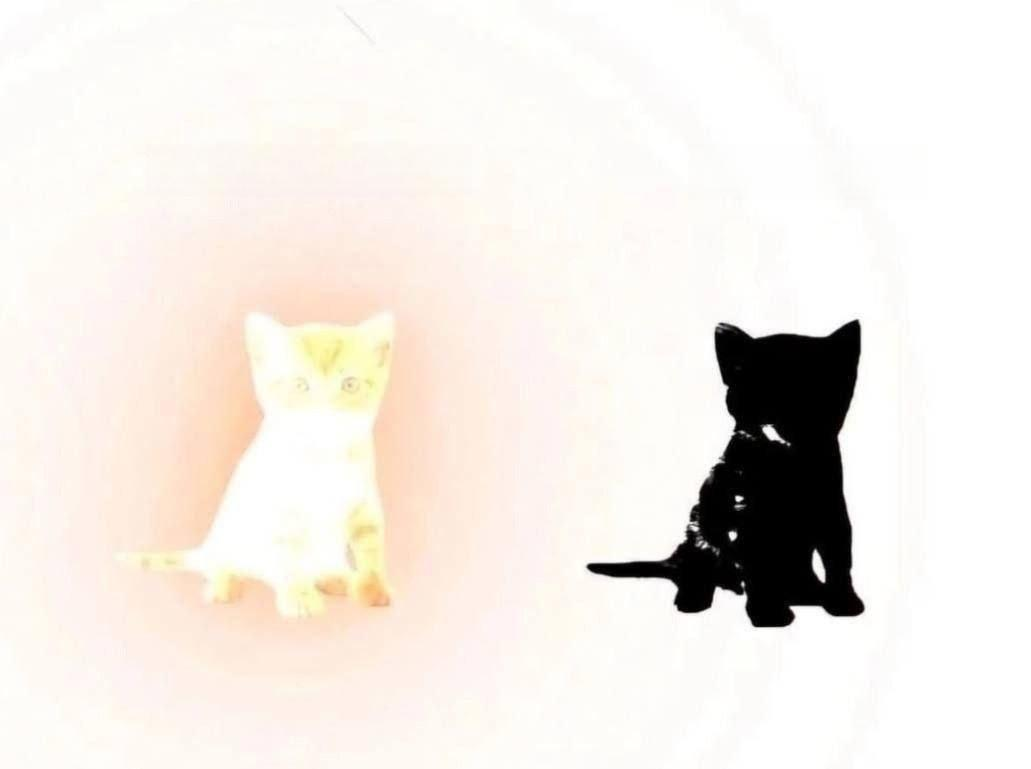


The image is a black and white photo of two cats sitting next to each other on the same side of the frame. The cat in the foreground appears larger than the one in the background, creating an interesting visual effect. There are no texts or additional objects present in the image, making it a simple yet intriguing composition that focuses solely on the two cats and their positioning within the frame.


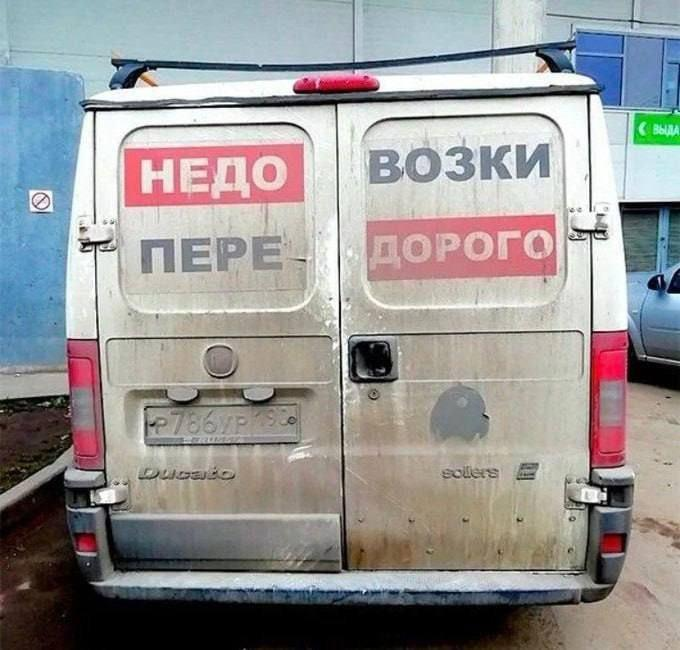


The image is a closeup of the back end of a silver van with red and white text on it. The text appears to be in Russian, but without any accompanying visual context or additional information, it's impossible to determine its meaning or interpretation.


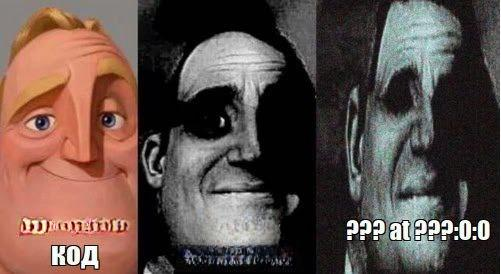


The image is a collage of three different images featuring the same person's face. The first panel shows an orange cartoon character with blue eyes and a red nose, while the second panel features a black and white portrait of the same individual. The third panel displays a black and white photograph of the same person.


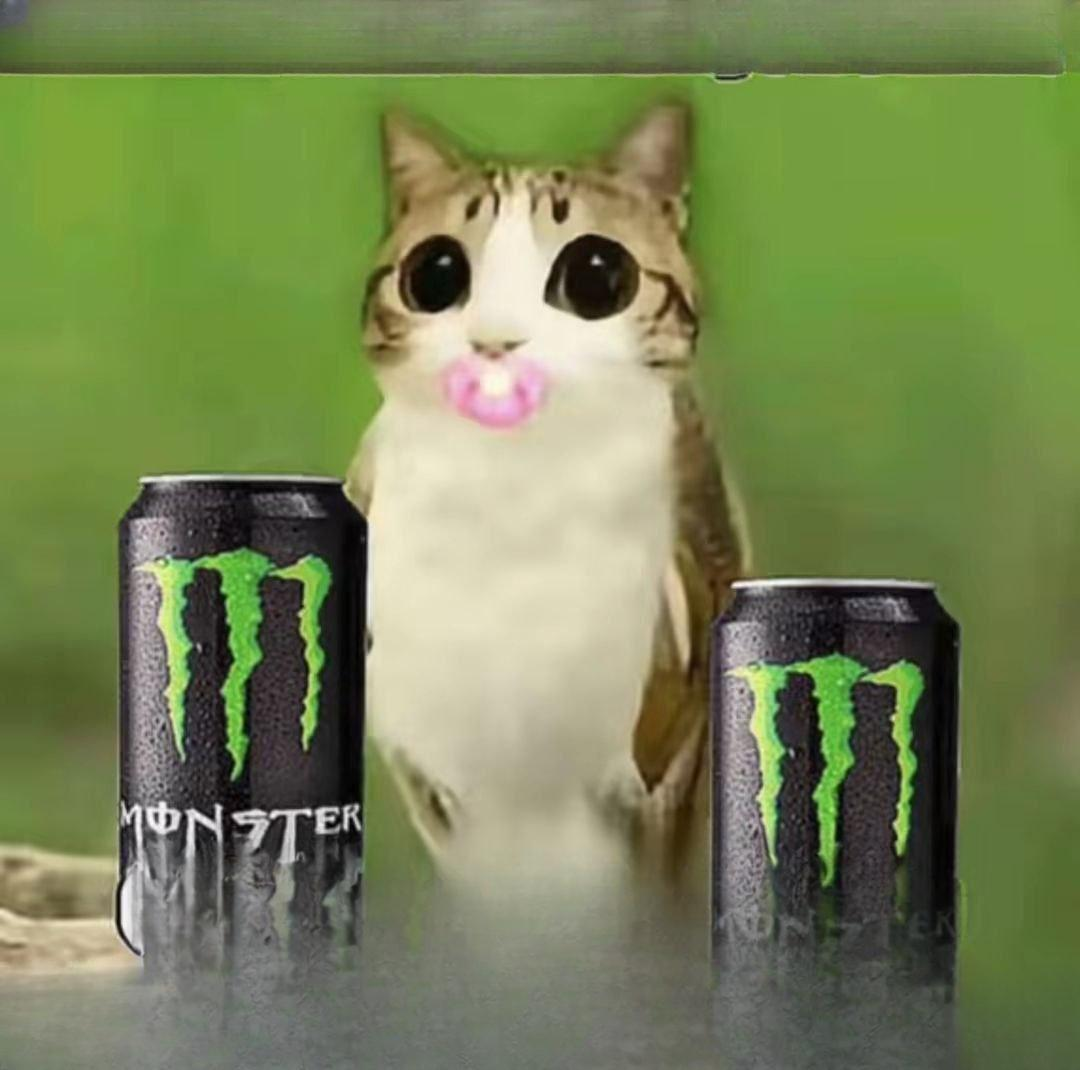


The image features a cat standing in front of two Monster energy drinks. The cat is positioned on the right side of the frame and appears to be looking at the camera, with its mouth open as if it's about to take a bite out of one of the drinks.


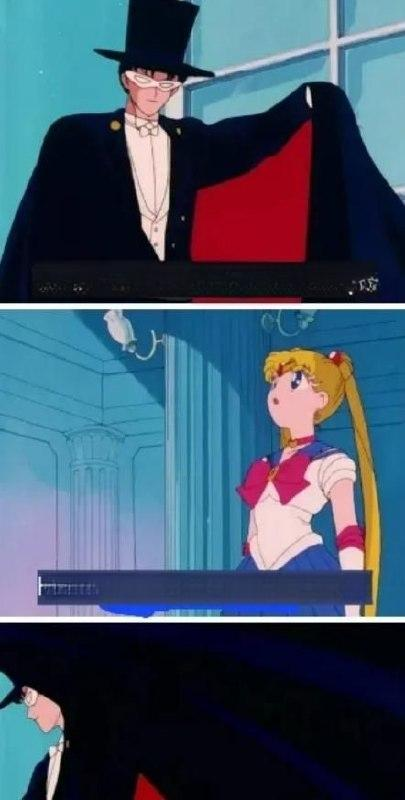


The image is a collage of three panels depicting characters from the anime "Sailor Moon". The first panel features a man in a top hat and coat, standing next to a woman with a red dress and blonde hair. The second panel shows the same man and woman together, but this time they are both wearing glasses. The third panel depicts the same scene, but the characters have changed their attire to black suits instead of the original top hat and coat.


In [111]:
sample = random.sample(meme_keys, 15)

for key in sample:
    show_result_moondream('clean_memes/' + key + '.jpg', promt_moondream)

Получили неплохой результат для картинок, на которых смогли распознать и вырезать текст (такие картинки все равно перевести не сможем из-за недостаточного качества распознавания на уровне OCR)
Попробуем более тяжелые модели для сравнения

Чтобы провести сравнение - нужно выработать критерии, по которым будем оценивать перевод картинки в текст и выбирать итоговую модель.

Первые два критерия будут техническими: вес модели в GB и количество параметров.

Остальные будут относиться к качеству перевода картинки в текст (будем размечать вручную):

0) Распознаны ли блоки текста? Правильно ли убран текст с фотографии?

    - да

    - нет

    Этот пункт технический, фото, для которых не распознан и не убран текст не будем учитывать в оценке VLM

1) Все ли есть в тексте, что я вижу на картинке? (полнота описания)

    3 - есть все

    2 - в основном все, пропущены мелкие детали

    1 - описана только часть объектов, опущены важные по смыслу детали

    0 - ни один из объектов на фото не описан в тексте

2) Есть ли в тексте что-то чего нет на картинке? (точность описания)

    3 - все, что есть в тексте, видно на картинке

    2 - в основном описание соответсвует, но модель додумала незначительные детали

    1 - многого, что есть в тексте, нет на изображении

    0 - в тексте все полностью придумано моделью и не находится на картинке

3) Понимает ли модель структуру мема? (соблюдение структуры)

    3 - структура полностью соответсвует (количество кадров, их порядок соблюдены достоверно)

    2 - структура немного отличается, но это не искажает понимание визуального контекста 

    1 - структура сильно отличается, но сохранены основные моменты (например, количество кадров соответсвует, но перепутан порядок)

    0 - структура полностью неправильная
    

Весь датасет разметить руками будет сложно + большие модели работают долго, отберем 25 случайных фото из нашего датасета, чтобы прогнать их дальше через все модели и сравнить результаты:

In [123]:
sample25 = random.sample(meme_keys, 25)

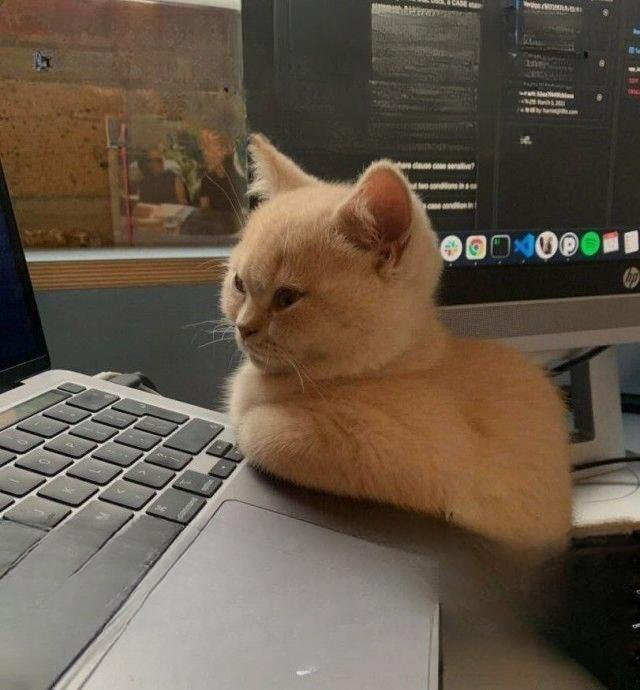

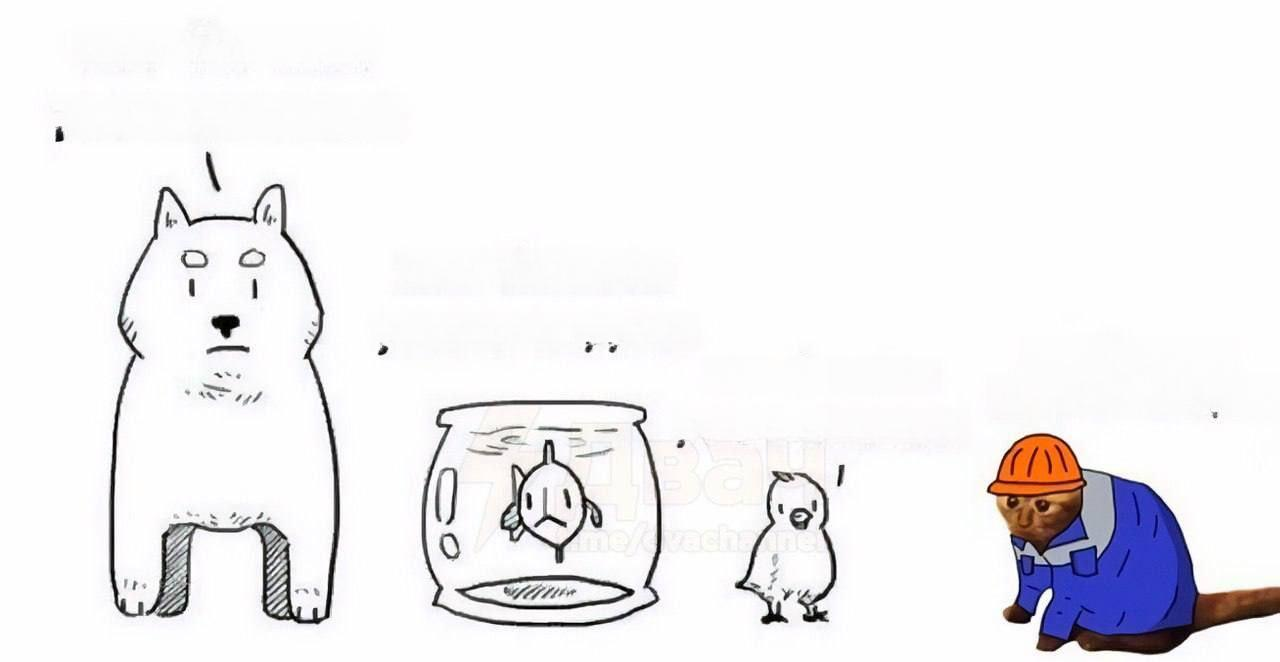

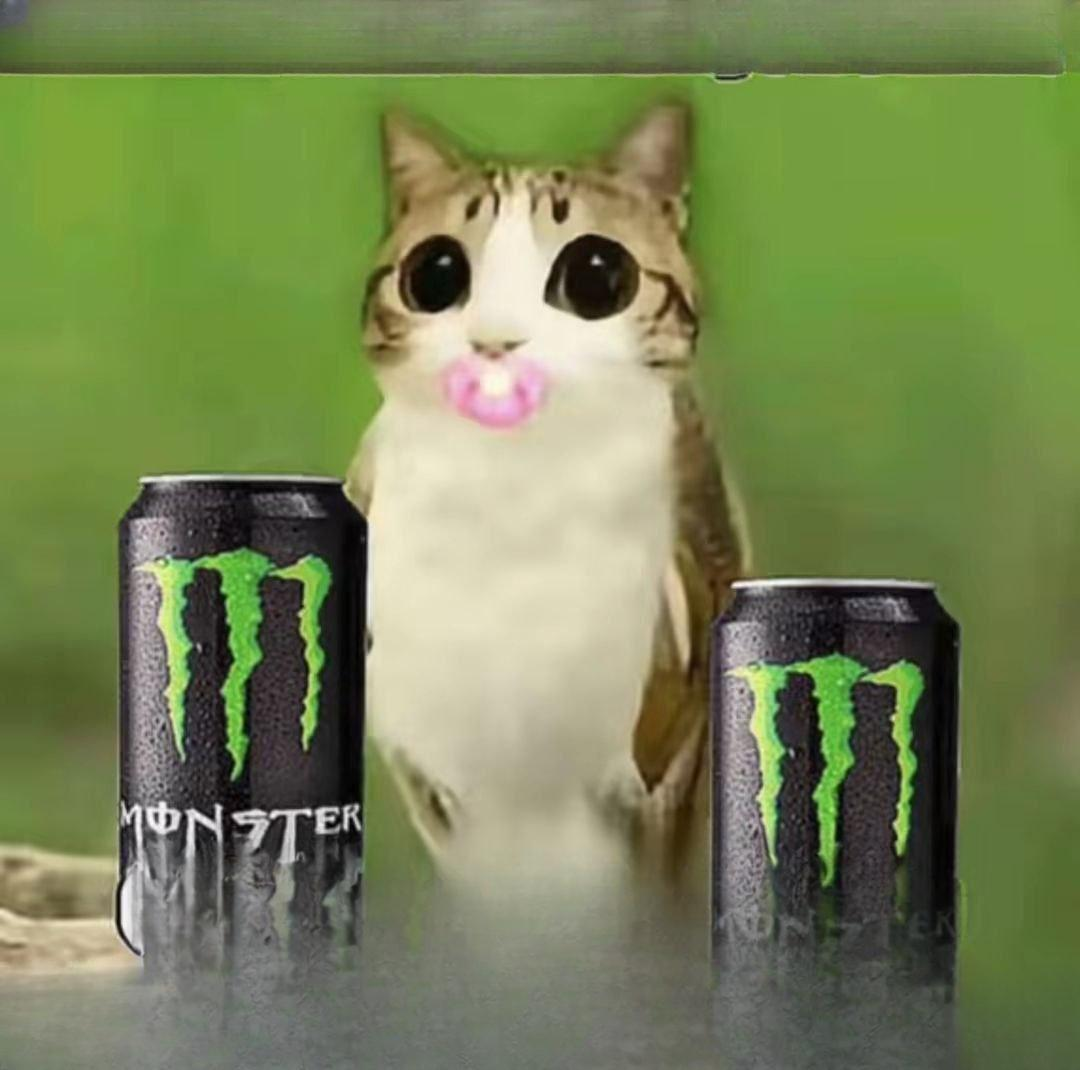

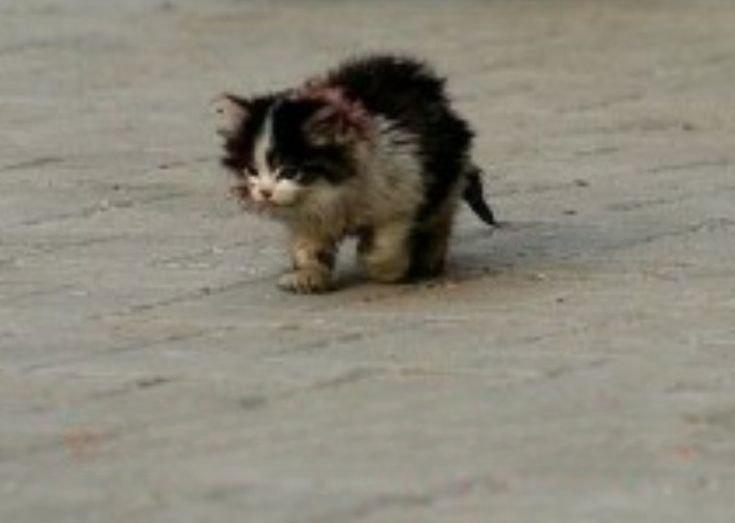

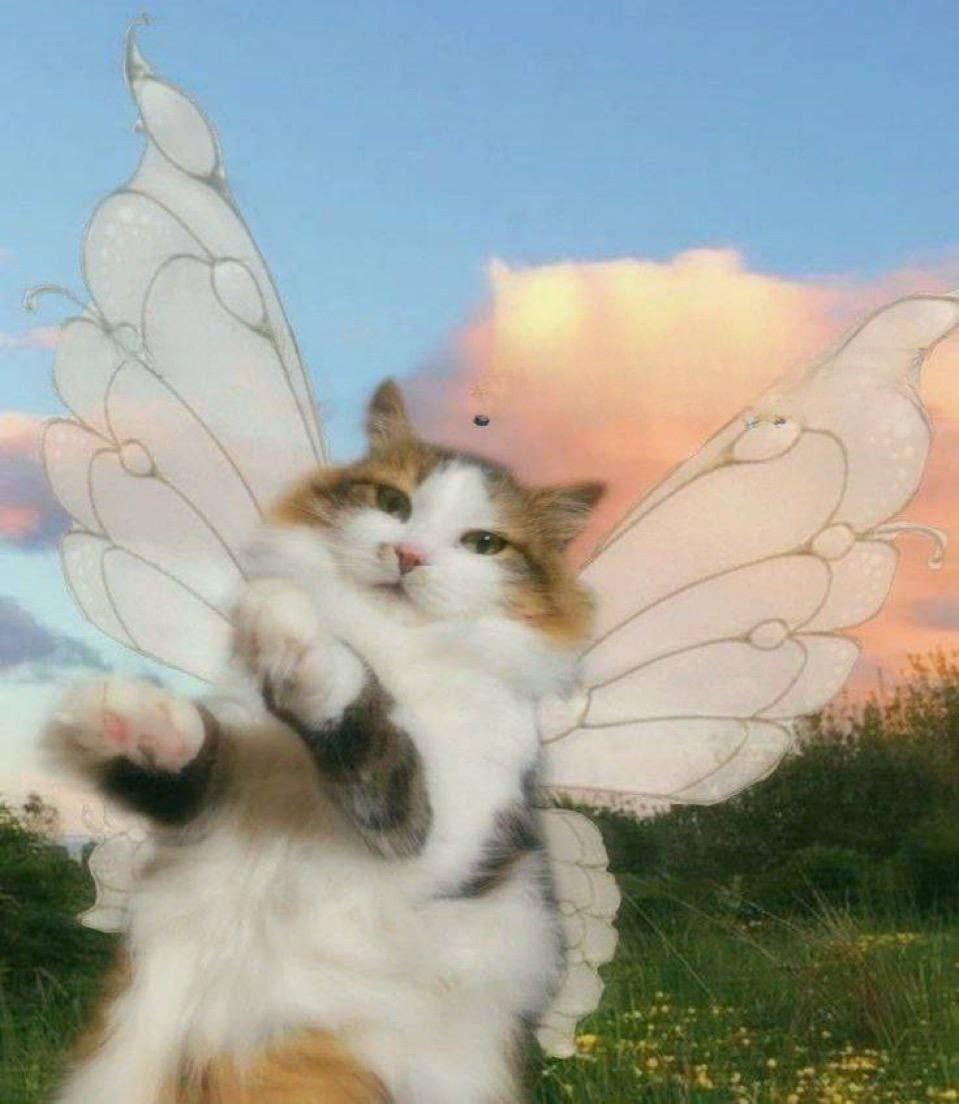

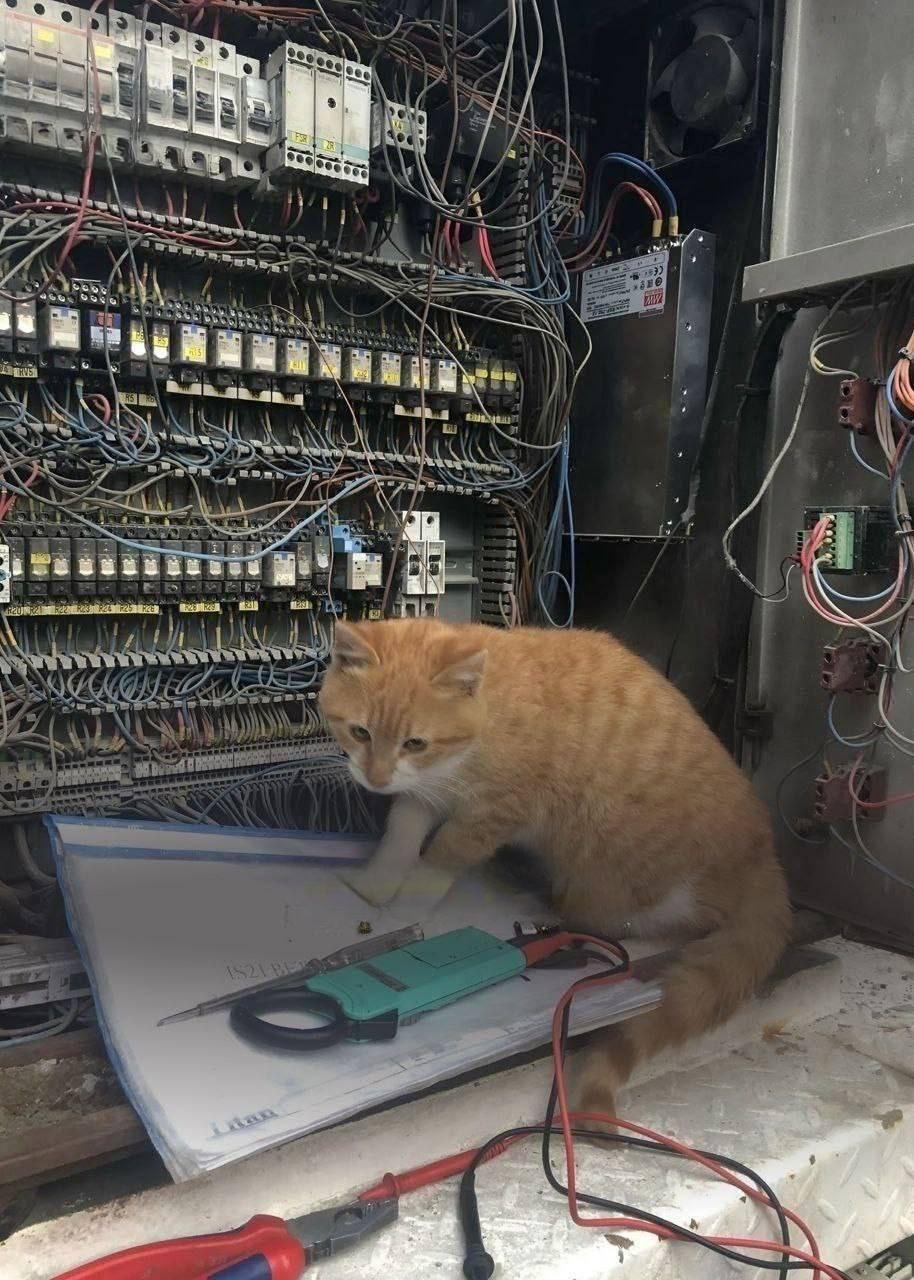

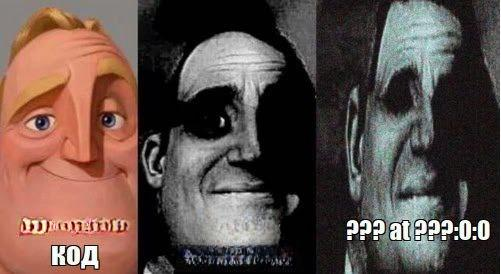

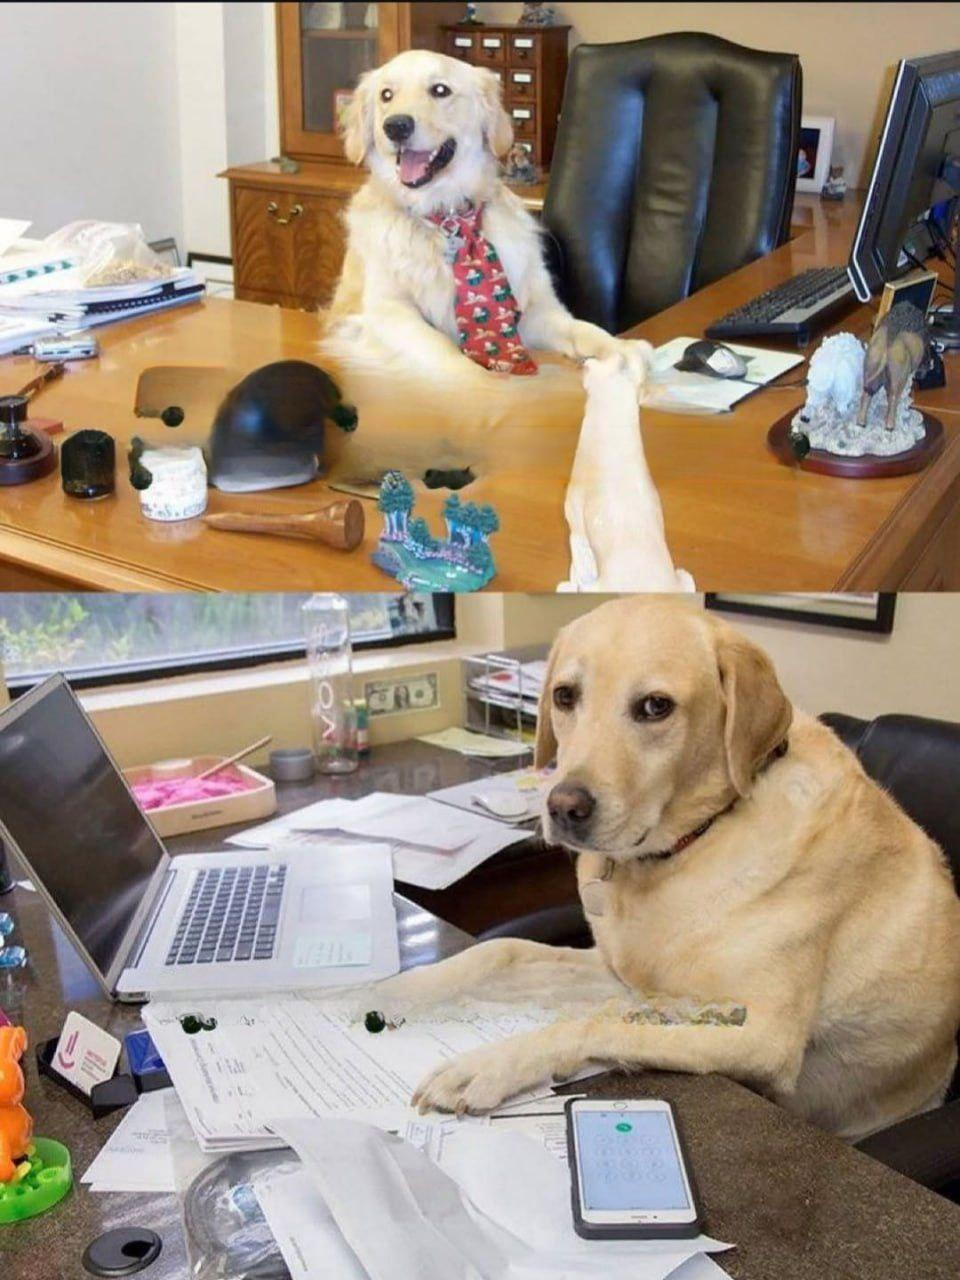

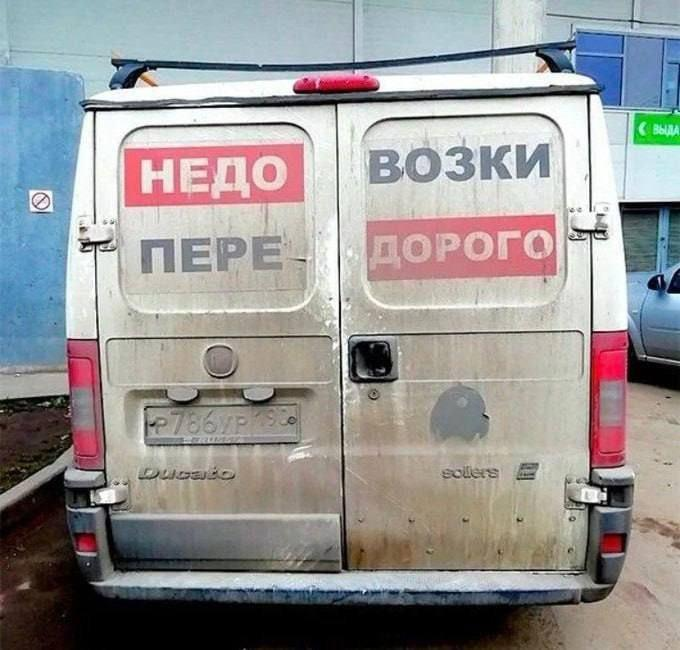

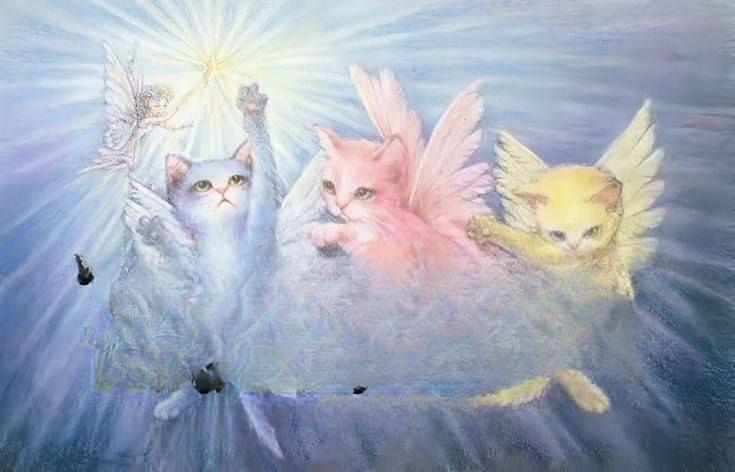

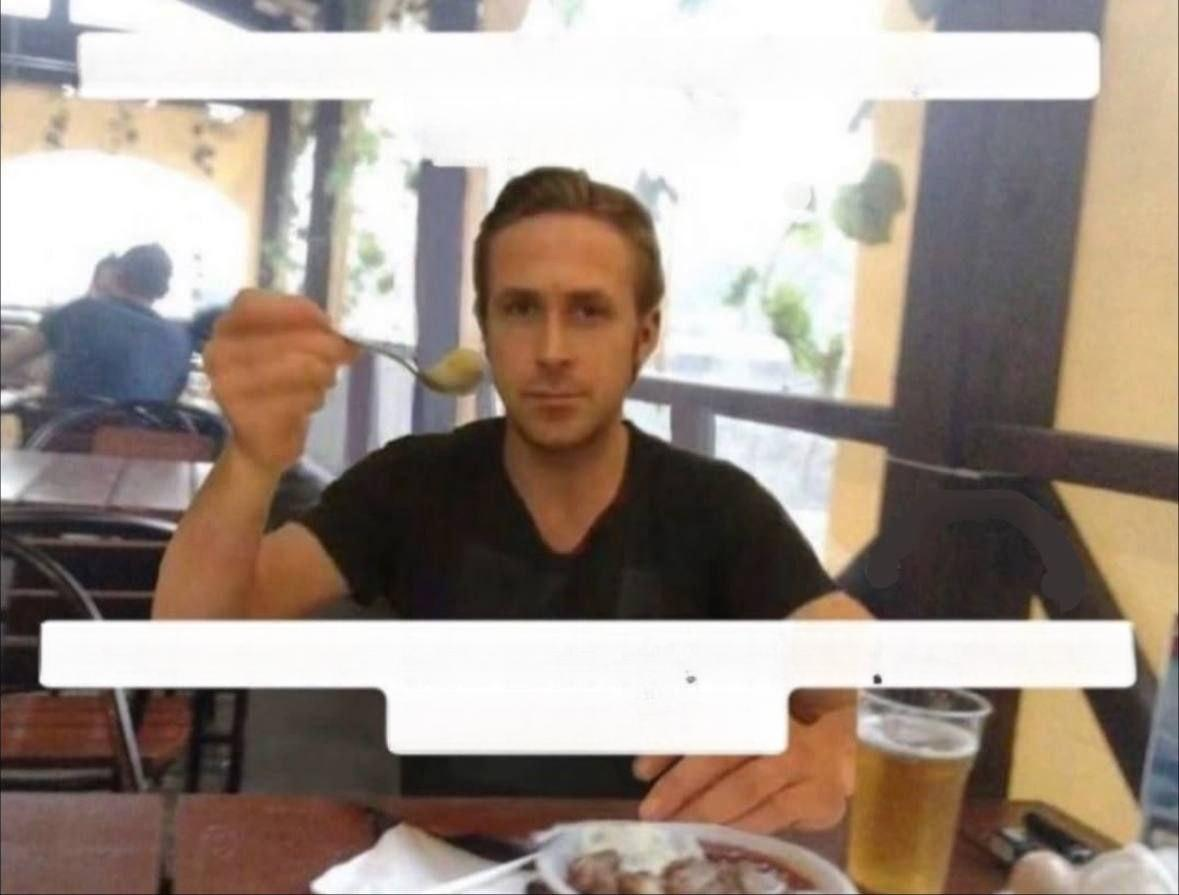

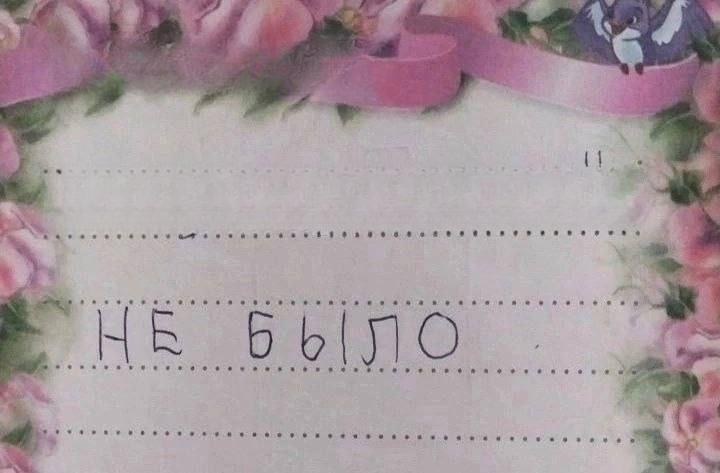

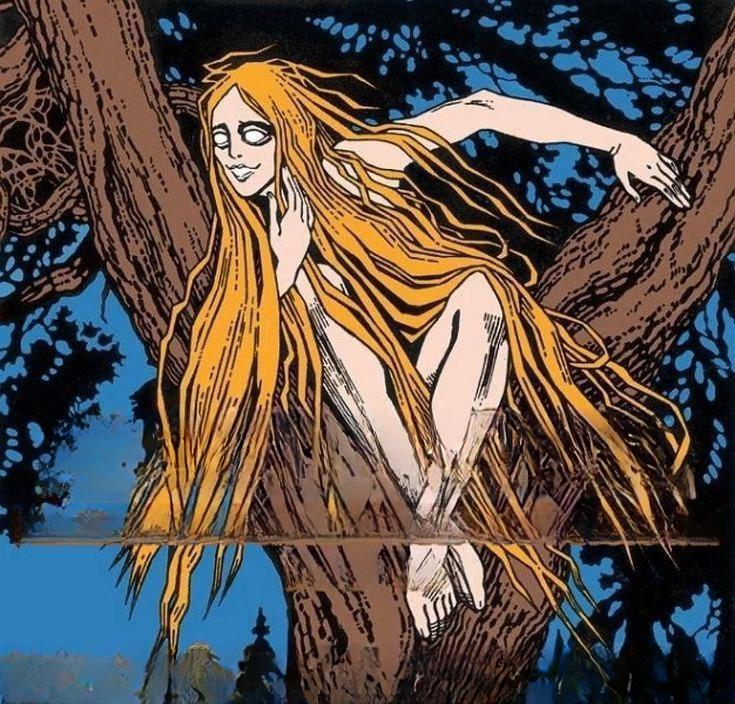

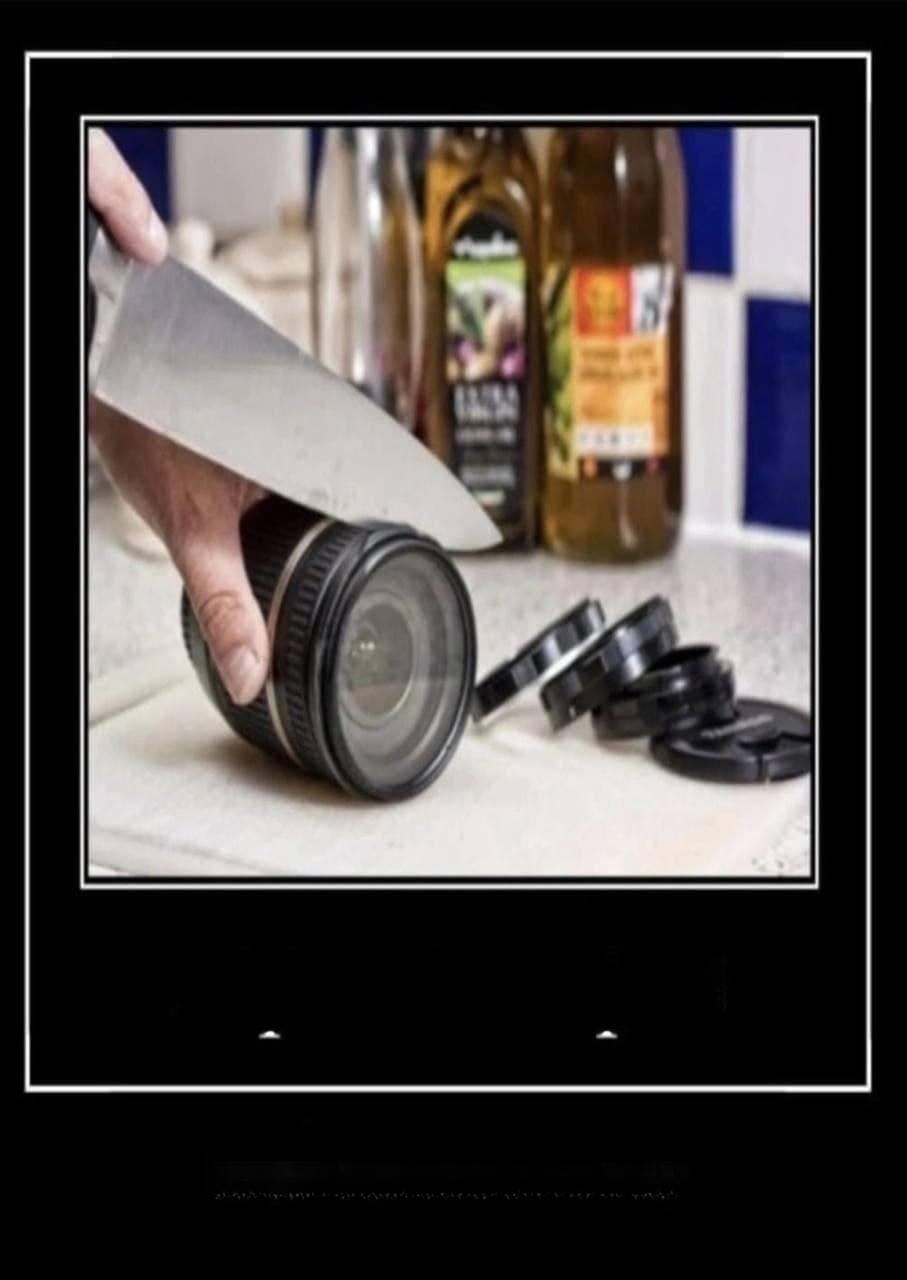

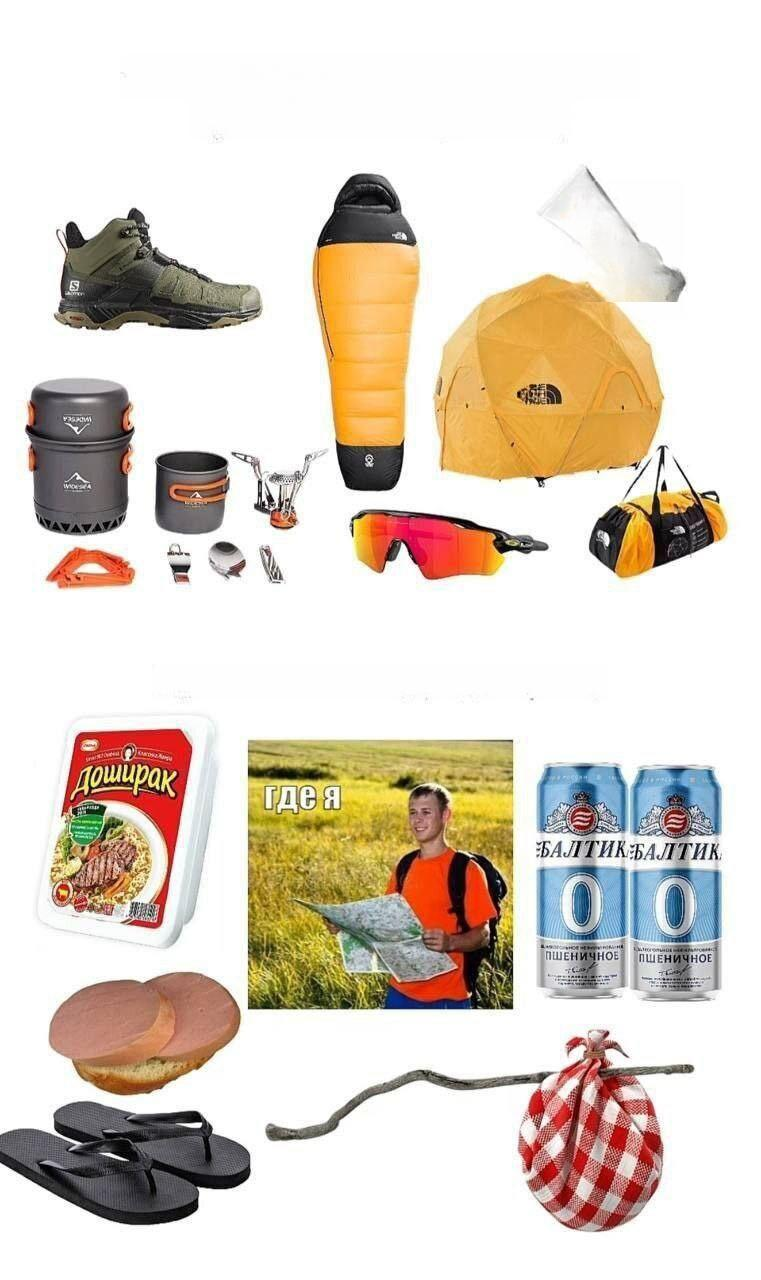

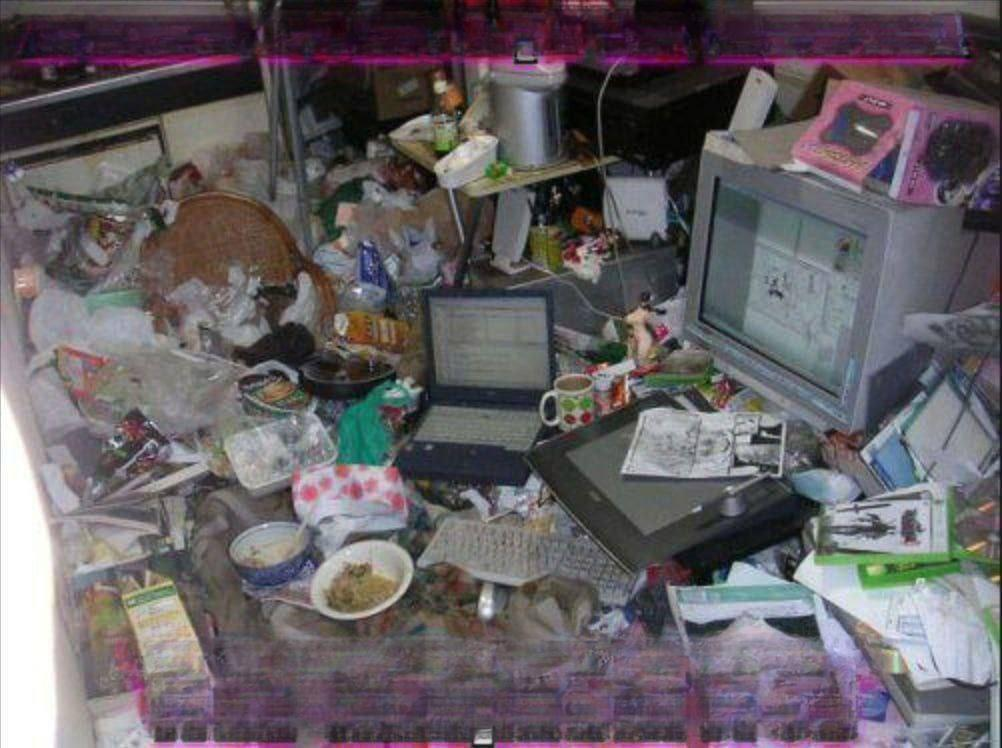

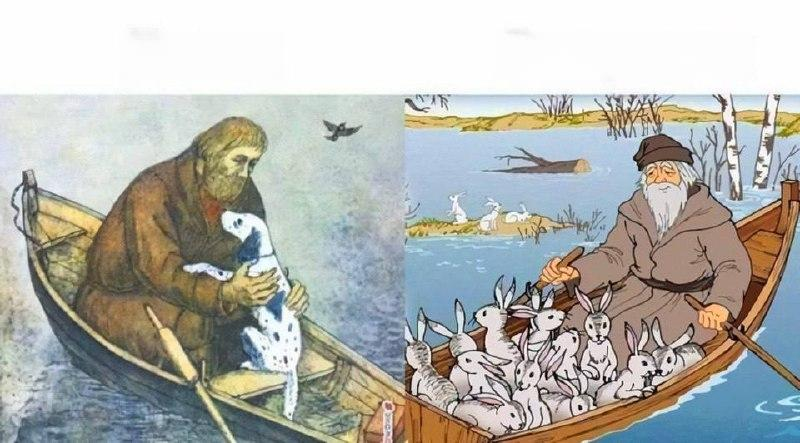

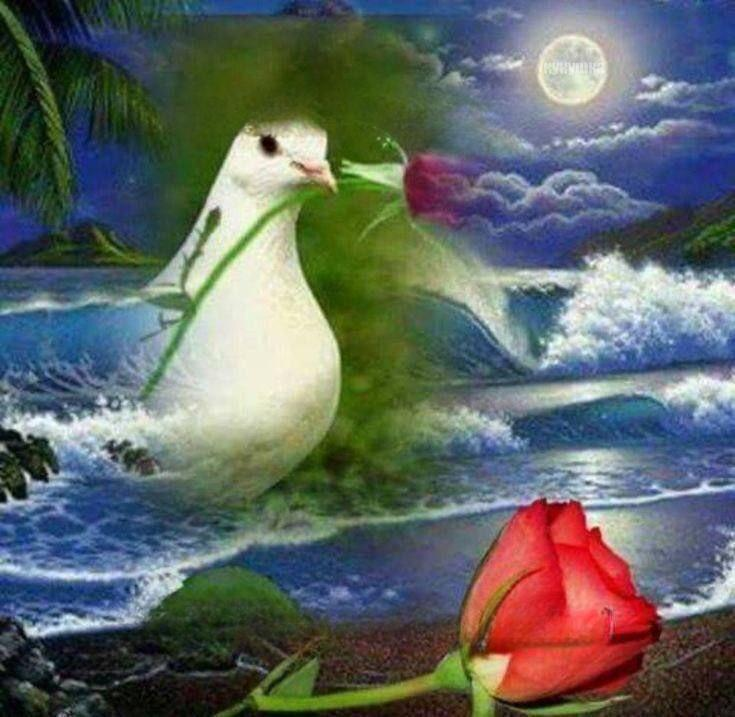

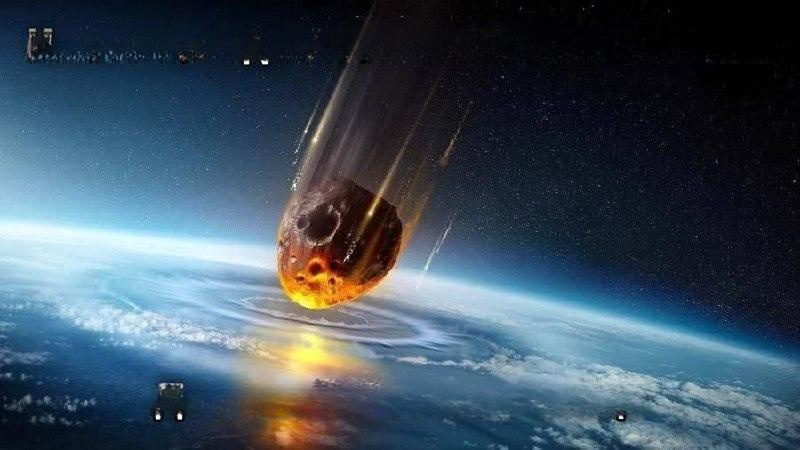

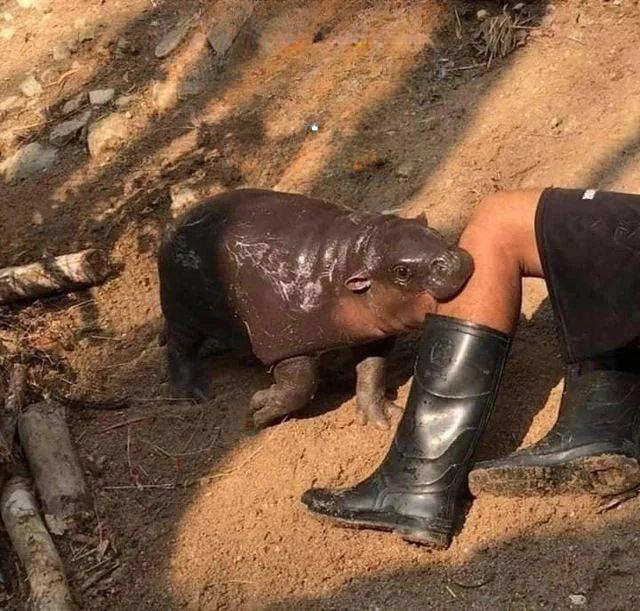

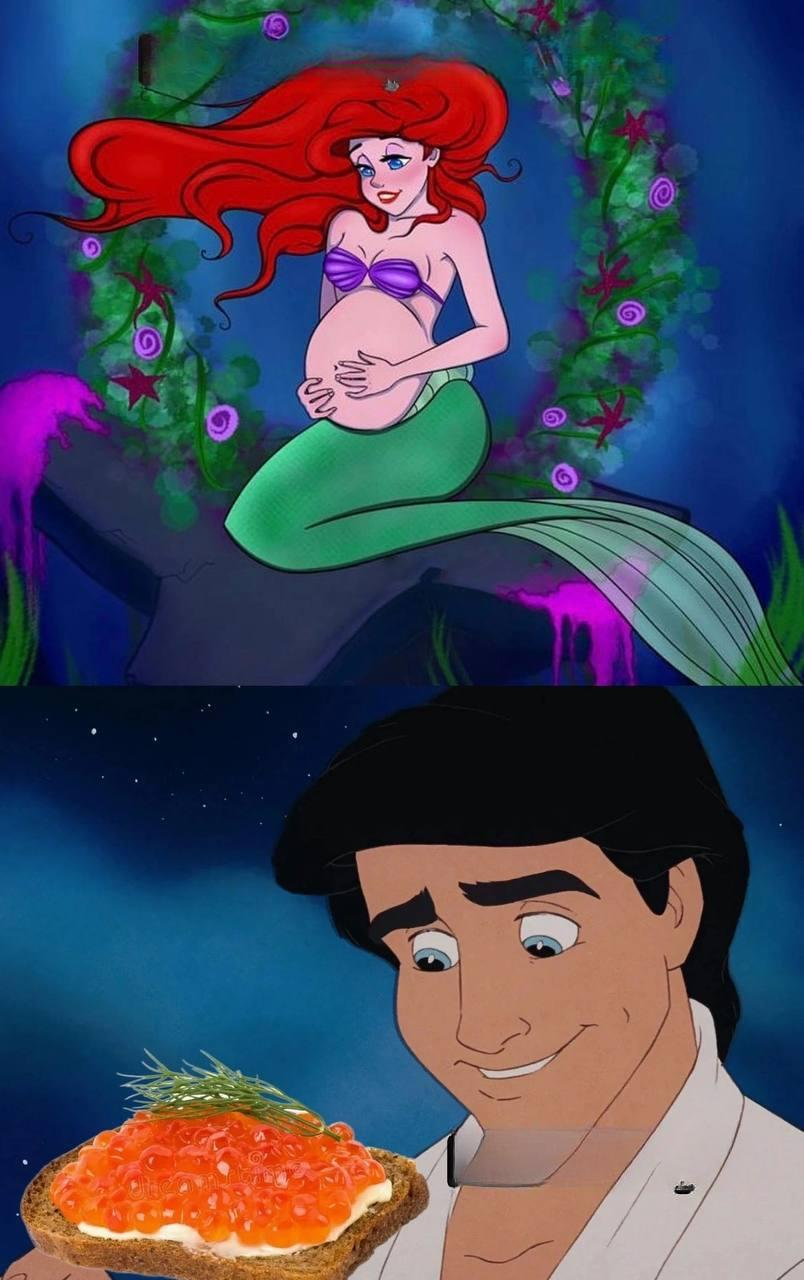

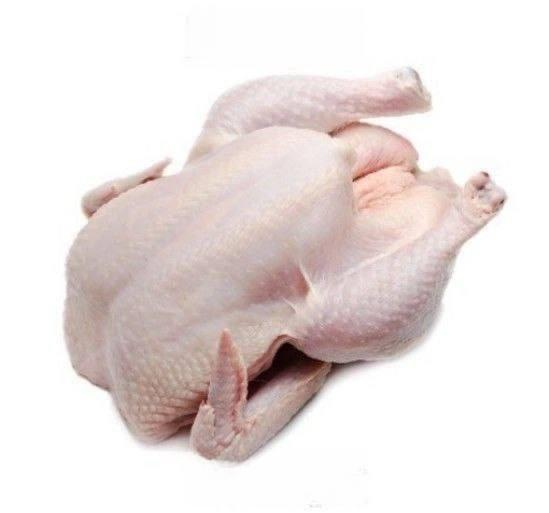

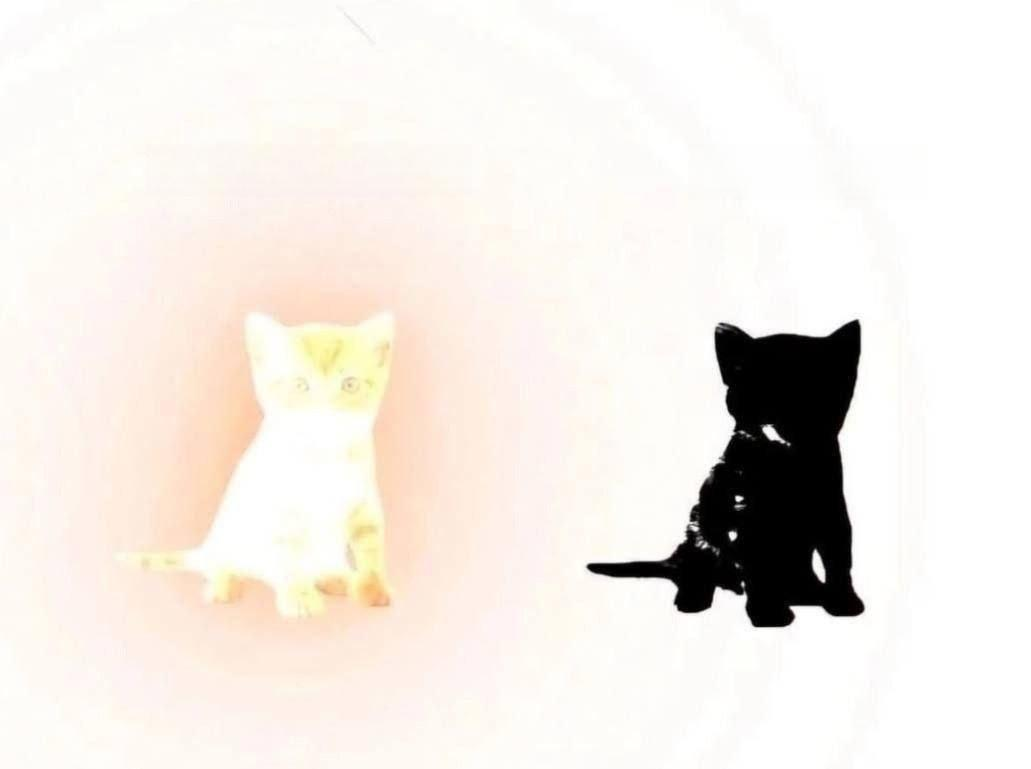

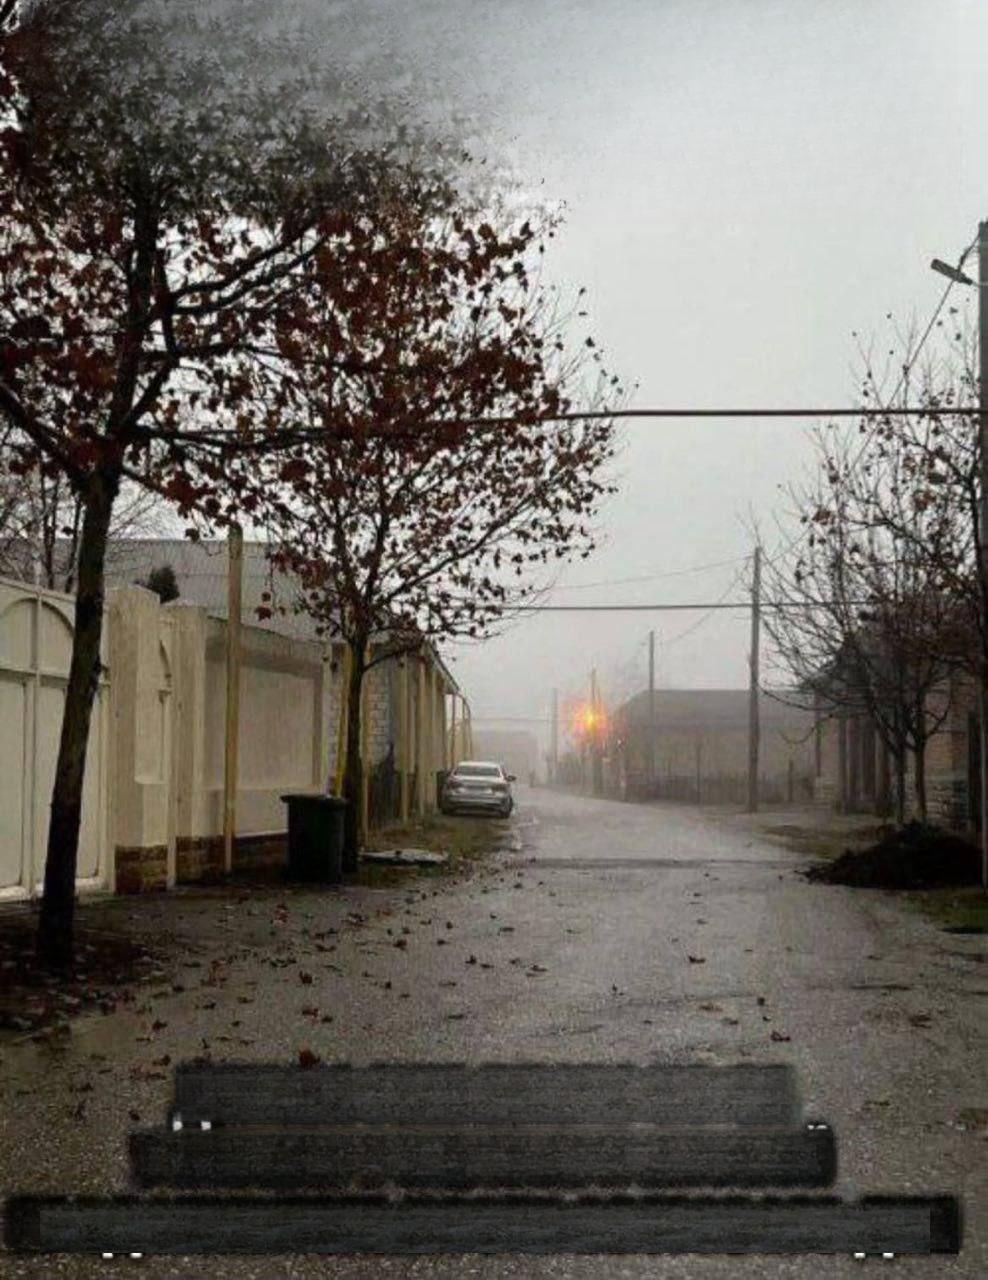

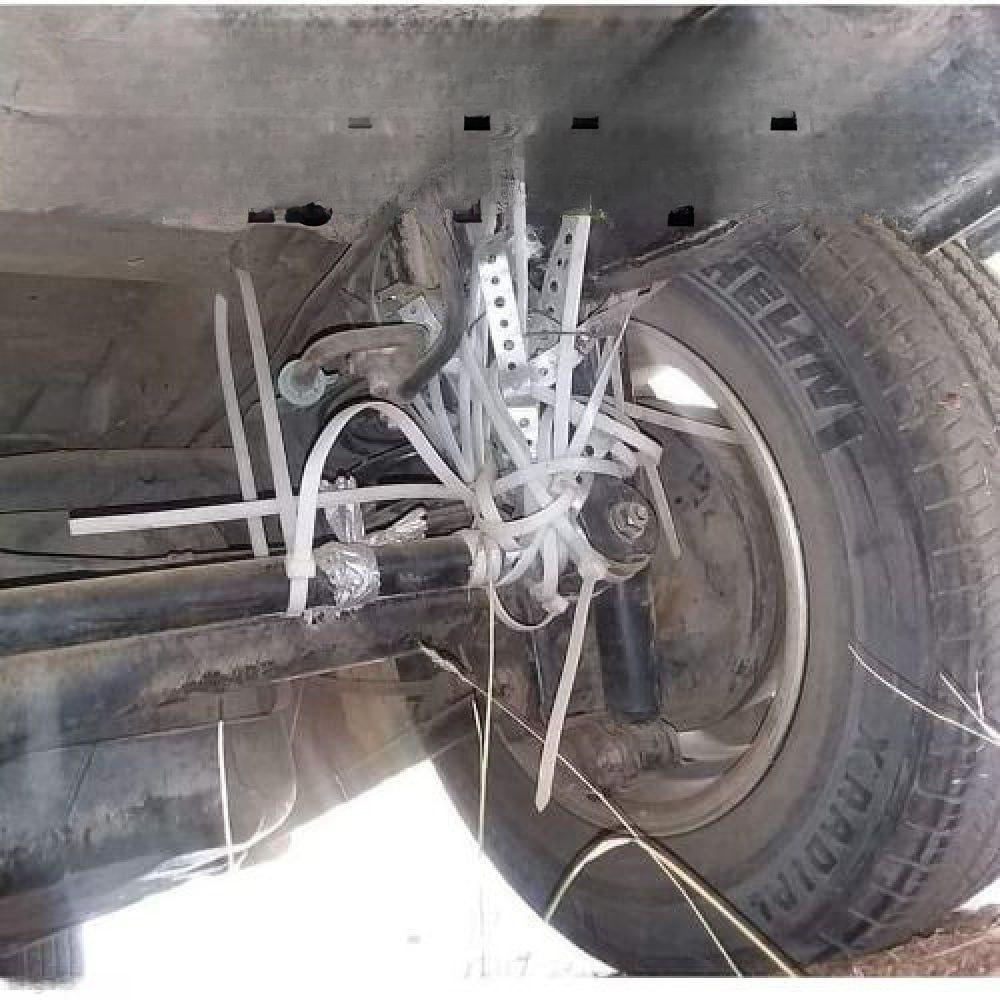

In [133]:
for key in sample25:
    display(DisplayImage(filename='clean_memes/' + key + '.jpg', width=200))

In [134]:
def save_result_moondream(img_path, promt):

    response = chat(
        model='moondream:v2',
        messages=[
            {
                'role': 'user',
                'content': promt,
                'images': [img_path]
            }
        ]
    )

    return response.message.content

In [135]:
moondream_results = {}
for key in sample25:
    moondream_results[key] = save_result_moondream('clean_memes/' + key + '.jpg', promt_moondream)
    print('||', end='')

||||||||||||||||||||||||||||||||||||||||||||||||||

In [136]:
moondream_results

{'AgACAgIAAxkBAAICDGmkRK4yvxzC4DuYNXRXyzJLORg0AAK2F2sbp6wgSQZ4nbsXNpIBAQADAgADeAADOgQ': '\nThe image features a small kitten sitting on the keyboard of an open laptop computer. The kitten is resting its head on the keys and appears to be looking at something in front of it, possibly a window or another object that caught its attention.',
 'AgACAgIAAxkBAAIBhGmkPNYPaeYmqtTEZ28G2H1OsdYTAALqD2sbVsbYS7LcsCgVh0SjAQADAgADeQADOgQ': '\nThe image is a black and white line drawing of three animals in different positions. The first animal is a dog standing on the left side of the image, while the second animal is a cat sitting on the right side. The third animal is a bird perched at the bottom center of the image.',
 'AgACAgIAAxkBAAIBeGmkPAEAAfyjVPbWkDe1ErTeL3J0AwACchhrGzdvwEh7Cl18go_IEQEAAwIAA3kAAzoE': "\nThe image features a cat standing in front of two Monster energy drinks. The cat is positioned on the right side of the frame and appears to be looking at the camera, with its mouth open as if i

### Qwen

In [112]:
def show_result_qwen(img_path, promt):

    response = chat(
        model='qwen2.5vl:3b',
        messages=[
            {
                'role': 'user',
                'content': promt,
                'images': [img_path]
            }
        ]
    )

    display(DisplayImage(filename=img_path, width=300))
    print(response.message.content)

In [119]:
prompt_qwen = """
You are a visual description system.

Your task is to describe all visible content in an image in a structured way.

OUTPUT FORMAT:
Start with "Panel 1:" and continue with Panel 2, Panel 3 if needed.
Do not write anything outside panel sections.

PANEL DETECTION:
- Split image into panels only if there are clear visual separations (borders, gaps, layout blocks)
- If not, use only Panel 1
- Use reading order: top-to-bottom, left-to-right

WHAT TO DESCRIBE:
Describe ALL visible elements, including:
- people, animals, objects
- background elements
- text regions (even if unreadable or empty areas where text likely exists)
- drawn or symbolic elements in the image

SPATIAL DESCRIPTION:
- Use simple spatial relations: left, right, above, below, inside, next to
- Do not use coordinates or numbers

CONSTRAINTS:
- Do NOT explain meaning, intent, humor, or story
- Do NOT add summaries or conclusions
- Do NOT add text outside panels
- Do NOT use phrases like "this image shows" or "we see"

COMPLETENESS RULE:
- If an element is clearly visible, it must be included
- Prefer completeness over brevity
"""

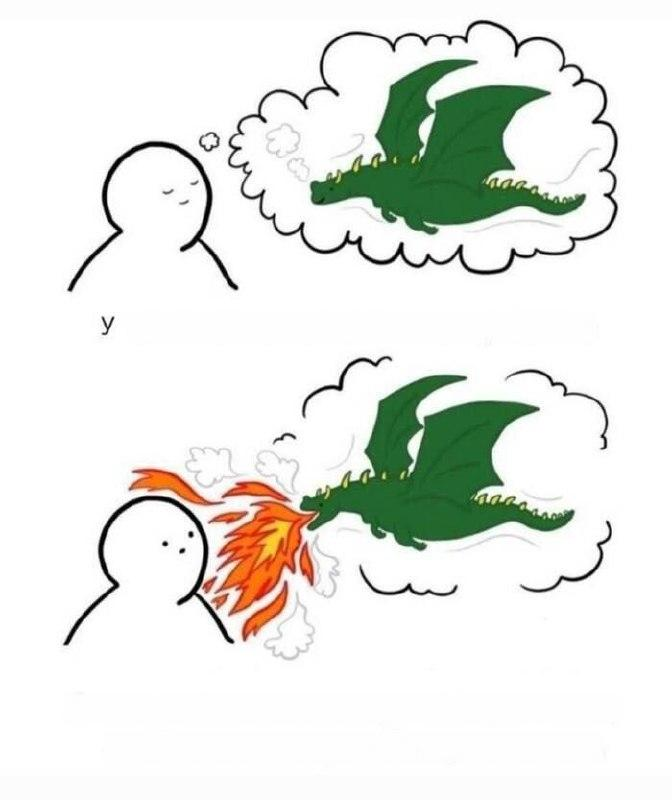

Panel 1: A simple, black-and-white drawing of a person with a thought bubble above their head. The thought bubble contains a green dragon with a small cloud around it.

Panel 2: The same person is shown again, this time with the dragon now emitting a large, fiery breath. The dragon is still inside the thought bubble, which now has a cloud around it.


In [120]:
show_result_qwen('clean_memes/' + meme_keys[0] + '.jpg', prompt_qwen)

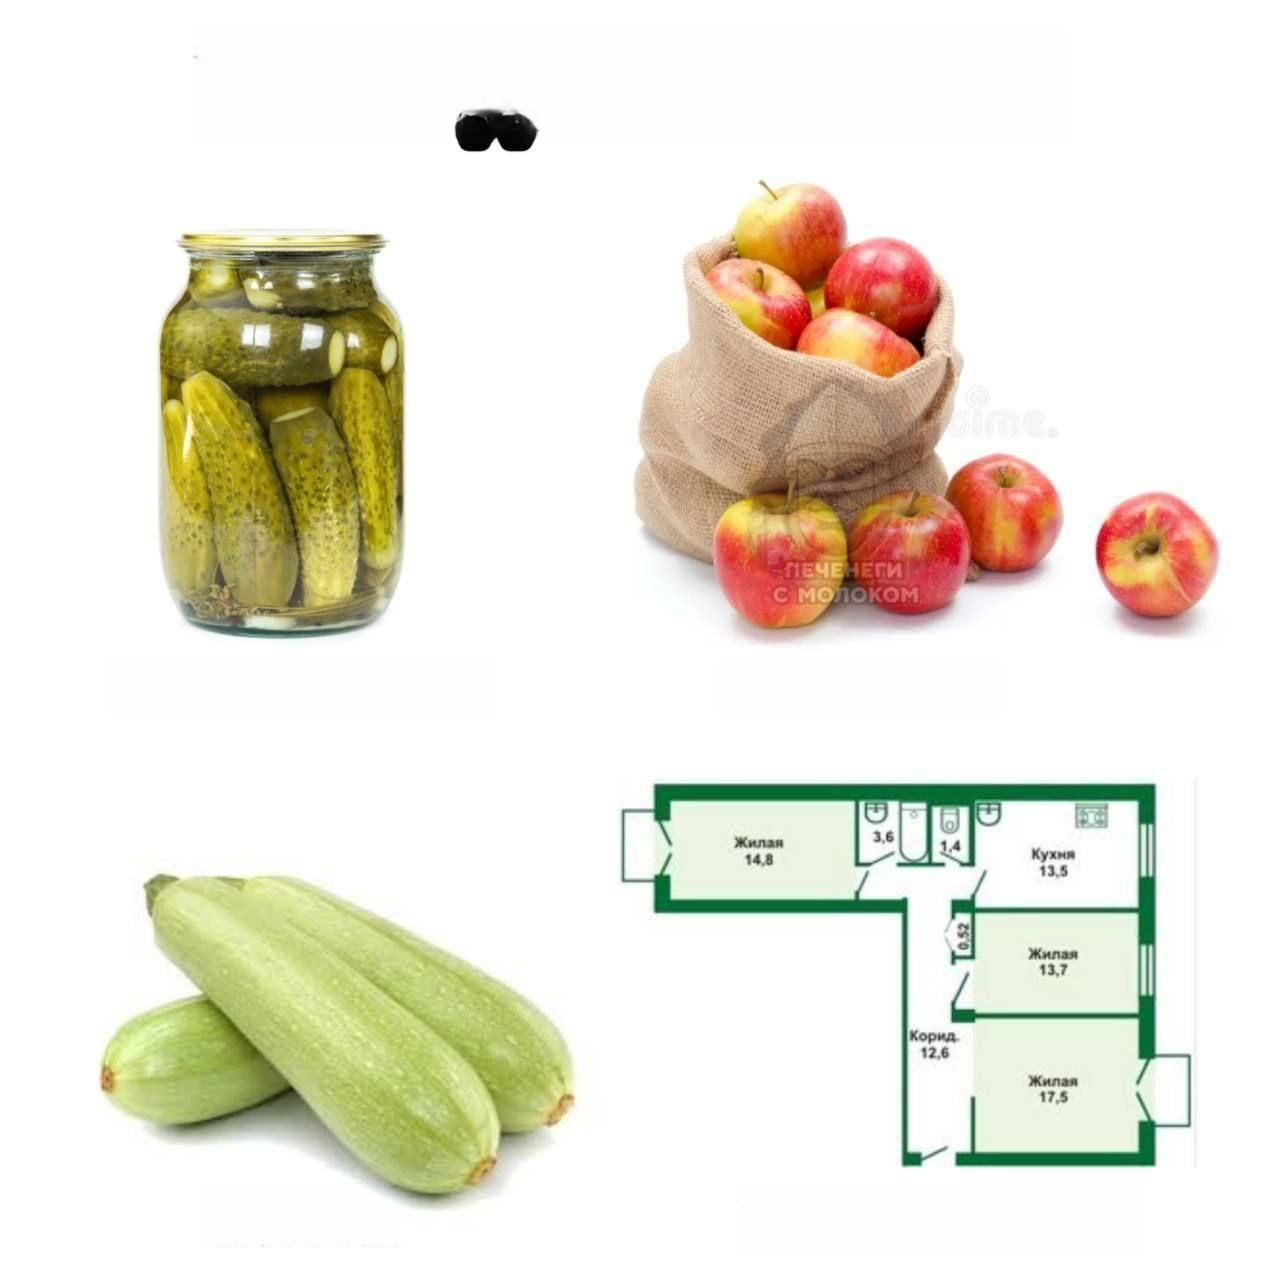

Panel 1: A jar of pickled cucumbers with a metal lid.
Panel 2: A beige sack filled with red apples.
Panel 3: A floor plan with labeled rooms and their sizes.


In [121]:
show_result_qwen('clean_memes/' + meme_keys[1] + '.jpg', prompt_qwen)

Прогоним наш сэмпл из 25 картинок и сохраним результаты:

In [124]:
def save_result_qwen(img_path, promt):

    response = chat(
        model='qwen2.5vl:3b',
        messages=[
            {
                'role': 'user',
                'content': promt,
                'images': [img_path]
            }
        ]
    )

    return response.message.content

In [126]:
qwen_results = {}
for key in sample25:
    qwen_results[key] = save_result_qwen('clean_memes/' + key + '.jpg', prompt_qwen)
    print('||', end='')

||||||||||||||||||||||||||||||||||||||||||||||||||

In [127]:
qwen_results

{'AgACAgIAAxkBAAICDGmkRK4yvxzC4DuYNXRXyzJLORg0AAK2F2sbp6wgSQZ4nbsXNpIBAQADAgADeAADOgQ': "Panel 1: A light orange cat is sitting on a laptop keyboard, looking to the left. The laptop is open and the screen is visible, showing a desktop with various icons and a wallpaper. The background includes a wooden desk and a computer monitor displaying a webpage with text and icons. The monitor is placed on the desk, and there is a small object on the desk to the left of the monitor. The cat's tail is curled around the edge of the laptop.",
 'AgACAgIAAxkBAAIBhGmkPNYPaeYmqtTEZ28G2H1OsdYTAALqD2sbVsbYS7LcsCgVh0SjAQADAgADeQADOgQ': 'Panel 1: A large, white dog with a sad expression is standing next to a fishbowl. Inside the fishbowl, there is a small, sad-looking fish. To the right of the fishbowl, there is a small, white bird with a sad expression. To the far right, there is a small, brown animal wearing a hard hat and overalls, looking down.',
 'AgACAgIAAxkBAAIBeGmkPAEAAfyjVPbWkDe1ErTeL3J0AwACchhrGzd

### Llava

In [137]:
def show_result_llava(img_path, promt):

    response = chat(
        model='llava:v1.6',
        messages=[
            {
                'role': 'user',
                'content': promt,
                'images': [img_path]
            }
        ]
    )

    display(DisplayImage(filename=img_path, width=300))
    print(response.message.content)

In [203]:
prompt_llava = """
You are describing aт image for a person who cannot see it.

IMPORTANT:
- Do NOT analyze, interpret, or explain meaning, do not write anything about meaning or interpretation.
- Do NOT describe expressions.
- Do NOT describe style.
- Only describe visible visual objects.

OUTPUT FORMAT (STRICT):

- If the image has one scene:
  Panel 1:
  - [detailed description]

- If the image has multiple panels:
  Panel 1:
  - [detailed description]
  Panel 2:
  - [detailed description]
  ...
  Continue numbering panels sequentially (Panel 3, Panel 4, etc.) ONLY if they exist.

One object belongs strictly to ONLY one panel
Numbering panels use natural reading order: top-to-bottom, left-to-right

RULES:
- Describe ALL visible objects, characters, text areas (even if unreadable or missing).
- Include actions and positions.
- Do NOT analyze, interpret, or explain meaning.
- Do NOT infer impressions, emotions, mood, tone, or "sense" of the image.
- Do not skip background details.
- If a detail is unclear, partially visible, or uncertain, do NOT guess it.
- Do not merge panels.
- Panels are determined only by visual separation (borders, spacing, layout).
- Never mention "analysis", "image shows", "we can see", just describe directly.

NO TEXT RULE:
- Ignore all text in the image completely.
- Do NOT describe, transcribe, guess, or mention any text (including readable, unreadable, partial, blurred, or missing text).
- Do NOT write anything about text, words, labels, letters or speech, THERE IS NO TEXT.
"""

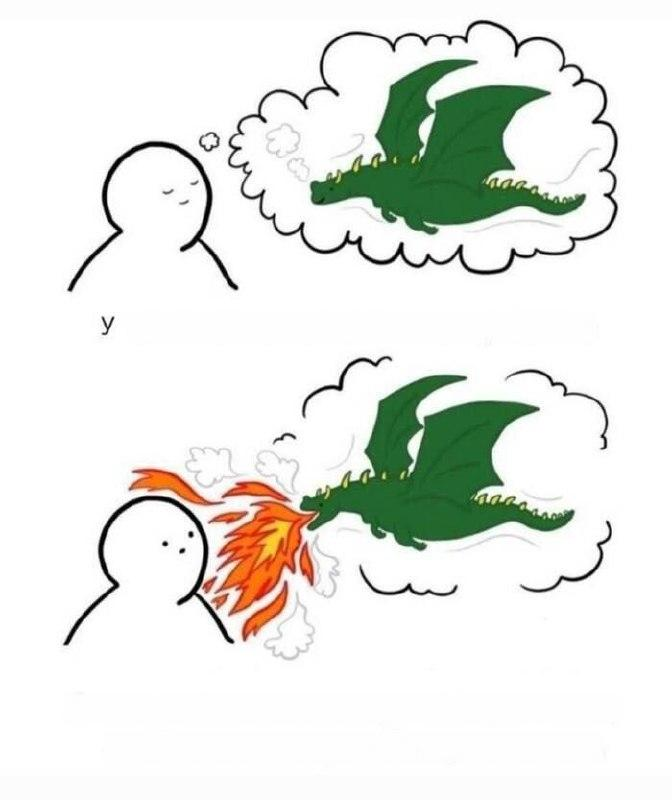

 Panel 1: A cartoon character with a thought bubble containing a green dragon with wings and flames blowing from its mouth. The dragon is white with black outlines.

Panel 2: The same cartoon character with a different thought bubble, now depicting the dragon's head being blown away by a blast of fire, indicating intense force or destruction. The dragon appears to be dissolving into flames. The character is in a state of shock, indicated by their wide-eyed expression and open mouth. 


In [204]:
show_result_llava('clean_memes/' + meme_keys[0] + '.jpg', prompt_llava)

In [206]:
def save_result_llava(img_path, promt):

    response = chat(
        model='llava:v1.6',
        messages=[
            {
                'role': 'user',
                'content': promt,
                'images': [img_path]
            }
        ]
    )

    return response.message.content

In [207]:
llava_results = {}
for key in sample25:
    qwen_results[key] = save_result_llava('clean_memes/' + key + '.jpg', prompt_llava)
    print('||', end='')

||||||||||||||||||||||||||||||||||||||||||||||||||

In [209]:
qwen_results

{'AgACAgIAAxkBAAICDGmkRK4yvxzC4DuYNXRXyzJLORg0AAK2F2sbp6wgSQZ4nbsXNpIBAQADAgADeAADOgQ': ' Panel 1:\nIn this panel, there is a scene featuring a cat sitting on the edge of a laptop keyboard. The laptop keyboard is black and white with several keys visible. The cat appears to be a light brown color, with its head resting on one hand and its tail curled around it. Its eyes are closed, suggesting that the cat may be asleep or very relaxed. In the background, there is a window with blinds partially open, allowing some natural light to enter the room.\n\nPanel 2:\nThe second panel shows the same scene as the first, but this time the cat has moved to another location on the laptop keyboard. It seems to be resting its paws on the computer mouse in front of it, and still appears to be napping or very relaxed. The window in the background has blinds fully closed, suggesting that it might be an evening or night scene. ',
 'AgACAgIAAxkBAAIBhGmkPNYPaeYmqtTEZ28G2H1OsdYTAALqD2sbVsbYS7LcsCgVh0SjAQADAg

Таблица с разметкой результатов: https://docs.google.com/spreadsheets/d/14_qTtIt9eH2MyaQ3m0KSeMl7m4wKu5OG4uY_3mwLd4k/edit?usp=sharing 

Итого, по выбранным 5 критериям для описания визуального контекста берем модель qwen2.5vl:3b